In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style("darkgrid")

# Preprocessing

In [39]:
parametrized_data = pd.read_csv('torgo_nopreemph_hamming256.csv', index_col=0)

In [40]:
parametrized_data.head()

,path,label,ASC,ASC_VAR,ASS,ASS_VAR,ASF1,ASF2,ASF3,ASF4,...,MFCC11,MFCC12,MFCC13,MFCC14,MFCC15,MFCC16,MFCC17,MFCC18,MFCC19,MFCC20
0,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,0,0.184410,2.844485,1.273322,0.220922,0.015476,0.015857,0.016008,0.016315,...,-7.778514,-10.919192,-4.185398,1.887481,-11.467344,-2.290919,-7.579661,-0.282507,-1.545831,-4.981239
1,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,0,0.277446,1.609560,1.213796,0.239385,0.010860,0.010890,0.011123,0.011627,...,-7.755306,-11.975713,-5.653173,2.960525,-11.595507,-4.439202,-7.003992,1.081950,-1.133004,-4.651984
2,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,0,1.302371,3.798506,1.562590,0.341607,0.029975,0.029691,0.029485,0.029375,...,-0.256529,3.685362,-6.653706,3.827842,-6.690595,-7.278024,-8.413125,8.260308,-3.556110,-7.026837
3,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,0,-1.541566,1.811958,1.361026,0.282031,0.008565,0.011450,0.013251,0.014728,...,-6.343857,-11.931686,-3.549286,3.298603,-12.613104,-5.415185,-8.174975,-1.634353,-1.733258,-5.088470
4,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,0,1.654178,1.164576,1.245388,0.075248,0.023994,0.023977,0.024223,0.024578,...,-1.878599,1.480944,-4.954466,2.208425,-8.516620,-7.300495,-9.873207,5.013566,-2.680927,-5.904635


In [41]:
parametrized_data.describe()

,label,ASC,ASC_VAR,ASS,ASS_VAR,ASF1,ASF2,ASF3,ASF4,ASF5,...,MFCC11,MFCC12,MFCC13,MFCC14,MFCC15,MFCC16,MFCC17,MFCC18,MFCC19,MFCC20
count,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,...,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17594.000000,17594.000000
mean,0.350145,-0.782094,1.284389,1.396764,0.223236,0.029333,0.033585,0.036858,0.039471,0.041784,...,-6.978791,1.693950,-4.215405,0.324436,-9.267599,-3.032001,-6.256118,3.355221,-5.069581,-4.308916
std,0.477029,1.885629,0.782782,0.194592,0.123602,0.059822,0.066962,0.074063,0.078232,0.083730,...,3.469089,3.747620,3.114617,2.498502,3.168573,2.657252,2.547337,2.227849,2.334446,2.276506
min,0.000000,-4.550933,0.027110,0.397898,0.003318,0.000080,0.000252,0.000552,0.000876,0.001195,...,-25.236315,-30.496828,-18.601119,-18.729565,-29.843425,-18.544276,-21.012648,-10.909122,-17.987459,-15.226478
25%,0.000000,-2.683019,0.711463,1.280318,0.136205,0.005770,0.008901,0.010240,0.012106,0.012916,...,-9.451721,-0.714341,-6.516663,-1.265476,-11.477398,-4.823552,-7.967061,1.934680,-6.695117,-5.993451
50%,0.000000,-0.794039,1.154022,1.389013,0.194263,0.018291,0.019274,0.019590,0.020495,0.021098,...,-7.035748,1.690285,-4.324599,0.497200,-9.448567,-2.937308,-6.500984,3.382575,-4.930001,-4.354092
75%,1.000000,1.161300,1.729409,1.495685,0.278617,0.026789,0.027342,0.027427,0.027562,0.027704,...,-4.500546,4.412338,-2.149349,2.067690,-7.232395,-1.050280,-4.797347,4.823446,-3.398264,-2.651237
max,1.000000,2.161076,7.578349,2.778215,1.136022,0.617158,0.645355,0.669565,0.749458,0.785794,...,9.253432,12.522576,15.590447,13.549545,12.995606,28.001638,26.836683,25.132935,17.776215,20.843233


### Dropping 'path' column

In [42]:
file_names = parametrized_data['path']
file_names = file_names.str.split('\\').str[-1]
parametrized_data = parametrized_data.drop('path', axis=1)

### Displaying number of NaN values

In [43]:
print("Number of NaN values:")
print(parametrized_data.isna().sum().sum())

Number of NaN values:
904


In [44]:
print("Number of NaN values:")
print(parametrized_data.isnull().sum().sum())

Number of NaN values:
904


In [45]:
print("Number of NaN values:")
print(parametrized_data.loc[:, parametrized_data.isna().any()])

Number of NaN values:
            LAT      ASP7      ASP8      ASP9     ASP10     ASP11     ASP12  \
0      0.484015  0.207756  0.105959 -0.007509  0.006592  0.121457  0.145897   
1      0.042969  0.149551 -0.180321 -0.047139  0.006995  0.110820 -0.038192   
2     -2.096910  0.040245  0.012333 -0.023296 -0.026949 -0.008912 -0.018222   
3     -0.028724  0.116275  0.108633  0.149639  0.126676  0.036103 -0.014044   
4     -0.036212  0.022620 -0.006500 -0.066760 -0.036428  0.026588  0.009179   
...         ...       ...       ...       ...       ...       ...       ...   
17622  0.151063 -0.141389  0.114016  0.067129  0.014543  0.059755  0.089707   
17623  0.221153 -0.232559  0.175838 -0.081666 -0.041109 -0.041161  0.045204   
17624  0.148603  0.027870 -0.011928 -0.015190 -0.045292 -0.020661  0.003727   
17625  0.020361  0.030764 -0.024325  0.090252  0.047648 -0.007858  0.049566   
17626  0.030195  1.172344 -0.019019  0.008538 -0.316039 -0.153770 -0.026944   

          ASP13     ASP14    

### Replace NaN values with 0

In [105]:
parametrized_data = parametrized_data.fillna(0)
print("Number of NaN values:")
print(parametrized_data.isna().sum().sum())

Number of NaN values:
0


In [47]:
parametrized_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17627 entries, 0 to 17626
Columns: 128 entries, label to MFCC20
dtypes: float64(127), int64(1)
memory usage: 17.3 MB


### Splitting data

In [48]:
parametrized_data_2 = parametrized_data.copy()
y = parametrized_data_2['label']
X = parametrized_data_2.drop('label',axis=1).copy()

### Scaling

In [49]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler,  MaxAbsScaler, PowerTransformer,QuantileTransformer
scaler = QuantileTransformer(n_quantiles=100, output_distribution='normal')
X = scaler.fit_transform(X)
data_2 = pd.DataFrame(X, columns=parametrized_data.columns[1:])

In [50]:
data_2.head()

,ASC,ASC_VAR,ASS,ASS_VAR,ASF1,ASF2,ASF3,ASF4,ASF5,ASF6,...,MFCC11,MFCC12,MFCC13,MFCC14,MFCC15,MFCC16,MFCC17,MFCC18,MFCC19,MFCC20
0,0.167028,1.863308,-0.722282,0.256459,-0.125541,-0.163018,-0.224410,-0.334324,-0.369105,-0.622260,...,-0.191916,-2.410190,0.037938,0.580174,-0.667481,0.224220,-0.487761,-1.667481,1.651924,-0.240286
1,0.192396,0.540368,-1.073900,0.413122,-0.266331,-0.500797,-0.588700,-0.721676,-0.799121,-1.119853,...,-0.186426,-2.441136,-0.384129,1.089522,-0.715471,-0.536524,-0.234341,-1.045945,1.876929,-0.117027
2,0.792147,2.325741,1.072130,1.048002,1.095213,0.973445,0.926625,0.893283,0.872337,0.789774,...,1.959946,0.516691,-0.721750,1.538168,0.822890,-1.571847,-0.887454,2.248042,0.607283,-1.174100
3,-0.084587,0.785872,-0.189791,0.698244,-0.373111,-0.456194,-0.434857,-0.450026,-0.347668,-0.524612,...,0.181552,-2.439799,0.230397,1.265196,-1.085264,-0.880960,-0.771483,-2.138415,1.551157,-0.285061
4,1.472685,0.014232,-0.891322,-1.843473,0.335146,0.280059,0.283761,0.295805,0.287962,0.167633,...,1.465980,-0.061671,-0.182432,0.728134,0.284588,-1.580360,-1.608135,0.777063,1.040158,-0.633927


## Plotting original data

In [51]:
n_features_per_plot = len(data_2.columns) // 8
indexes = []
for i in range(8):
    start_idx = i * n_features_per_plot
    end_idx = start_idx + n_features_per_plot
    indexes.append((start_idx,end_idx))
    

### Violing plots

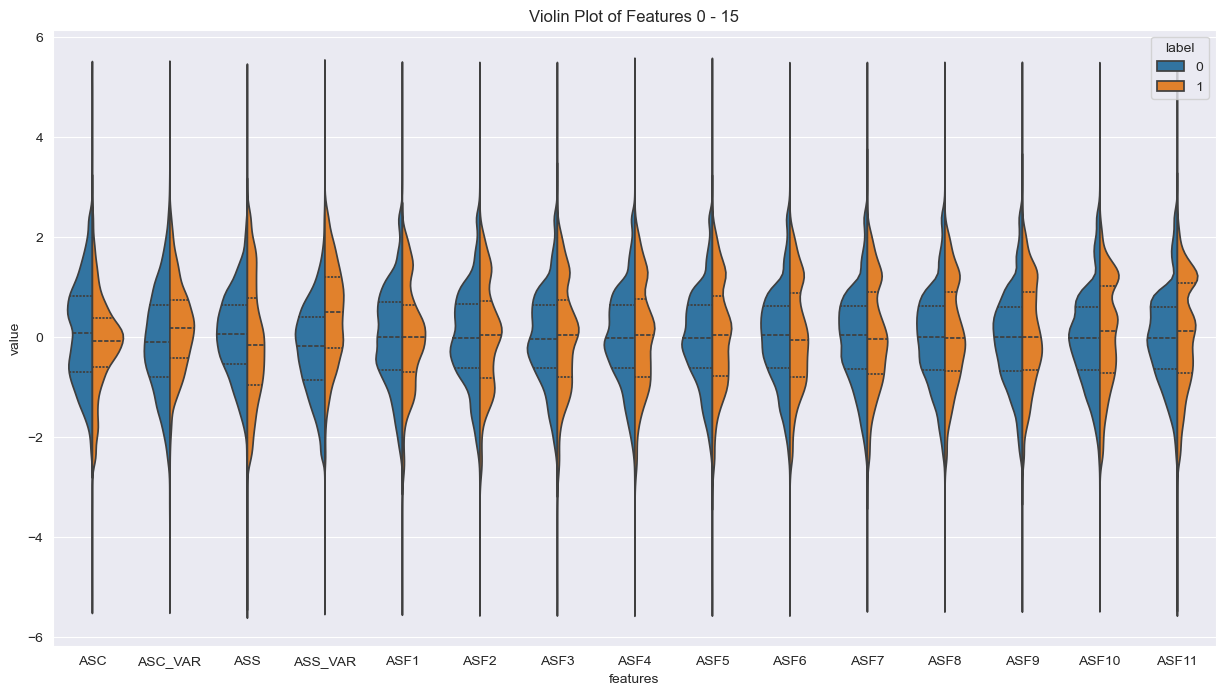

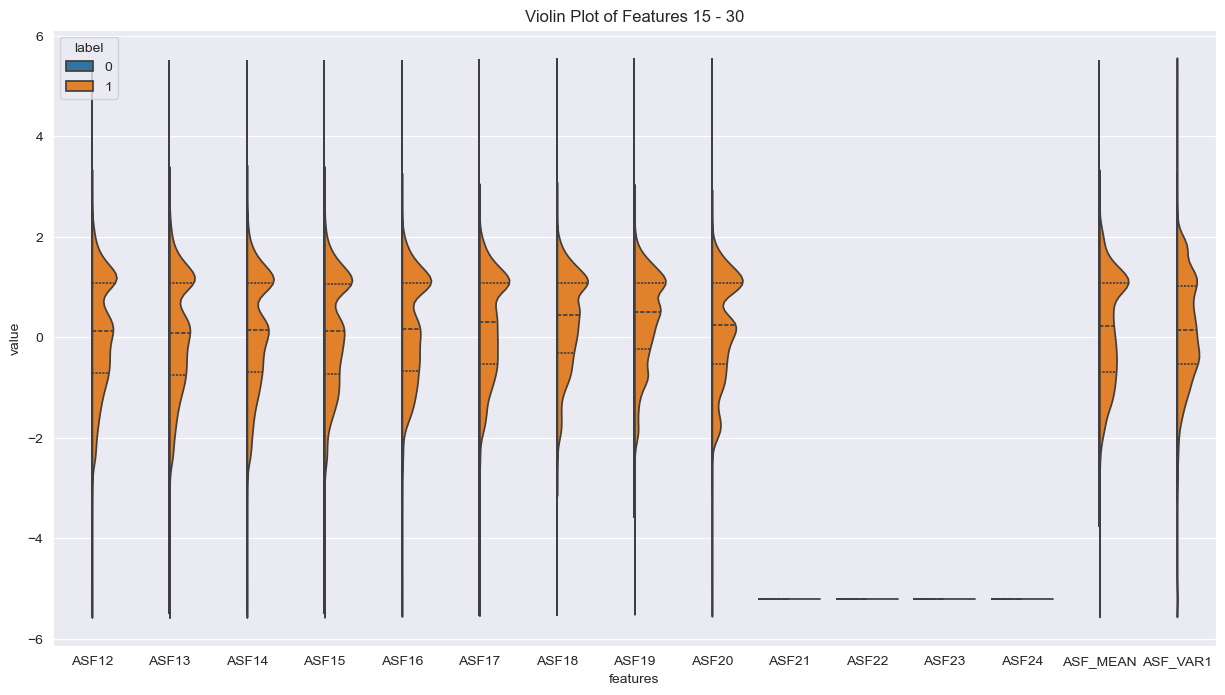

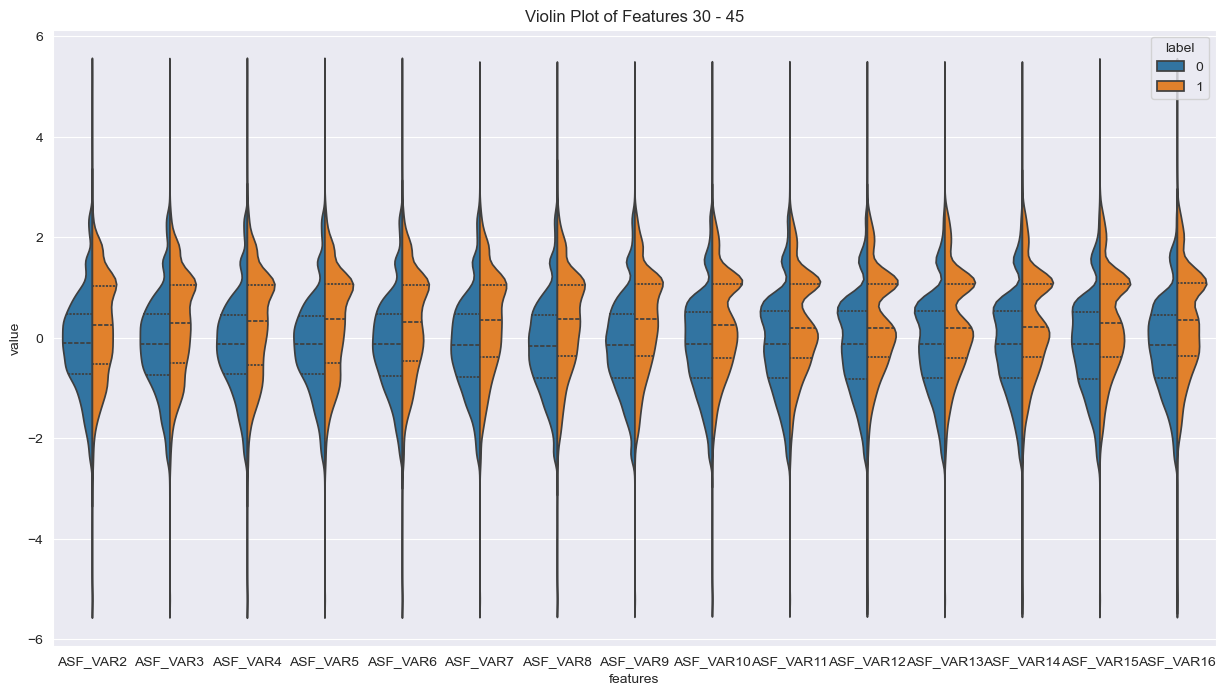

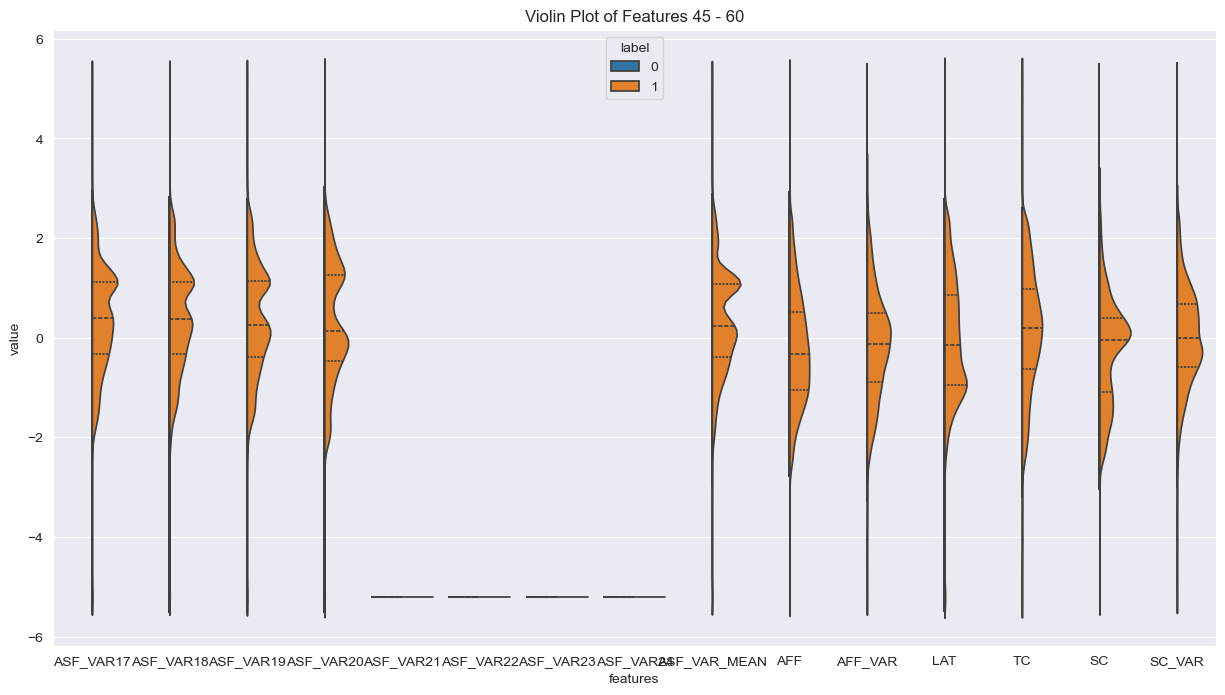

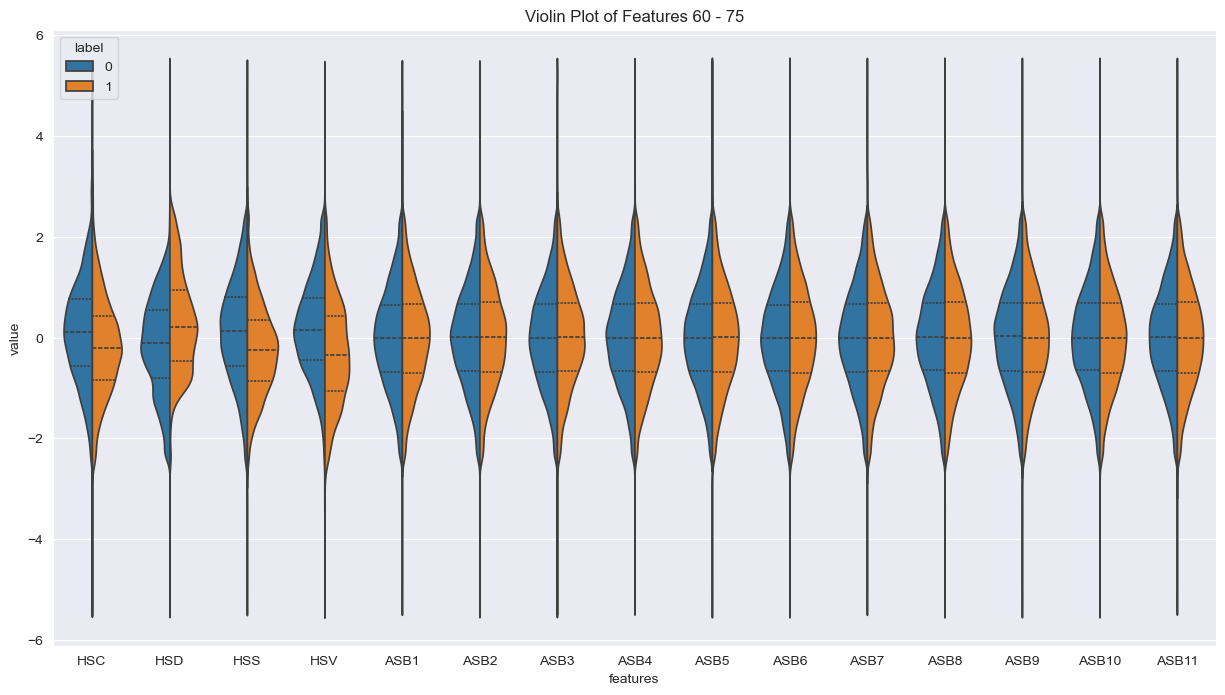

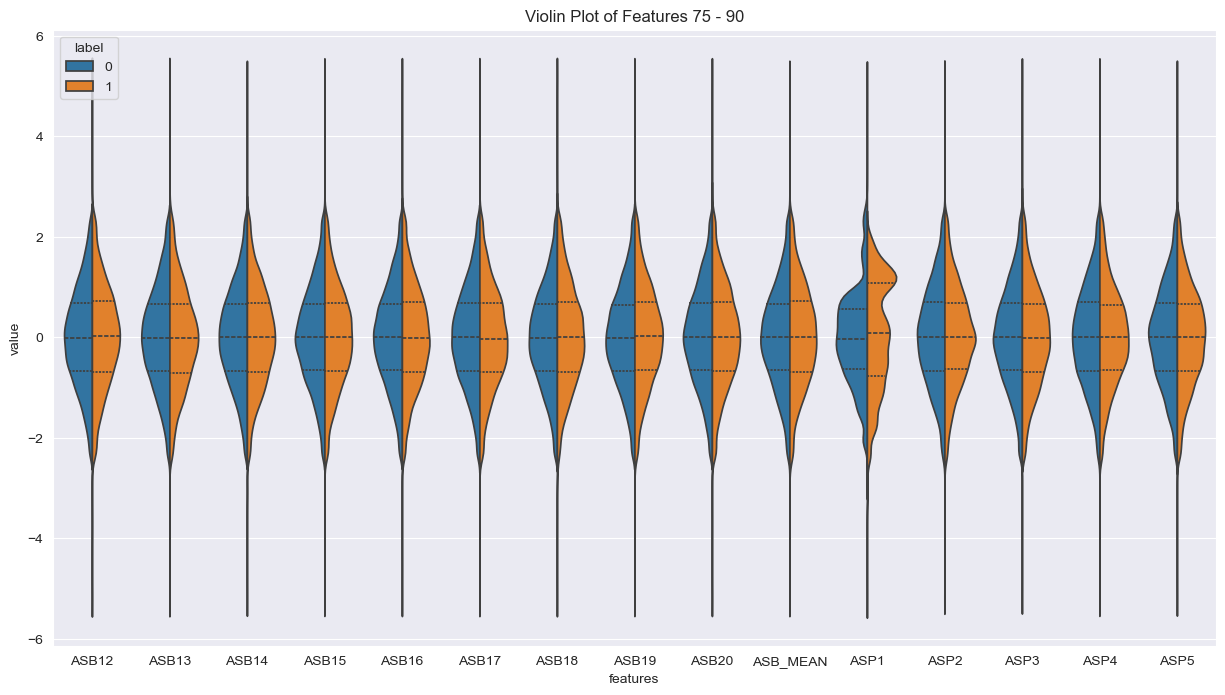

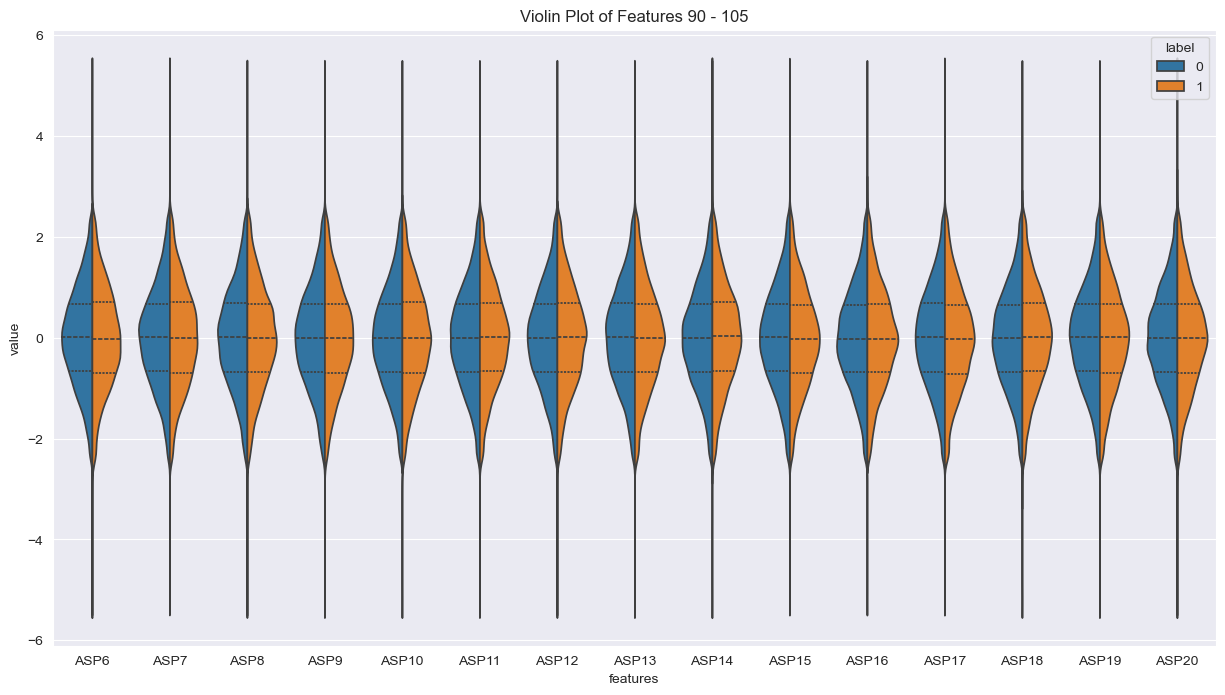

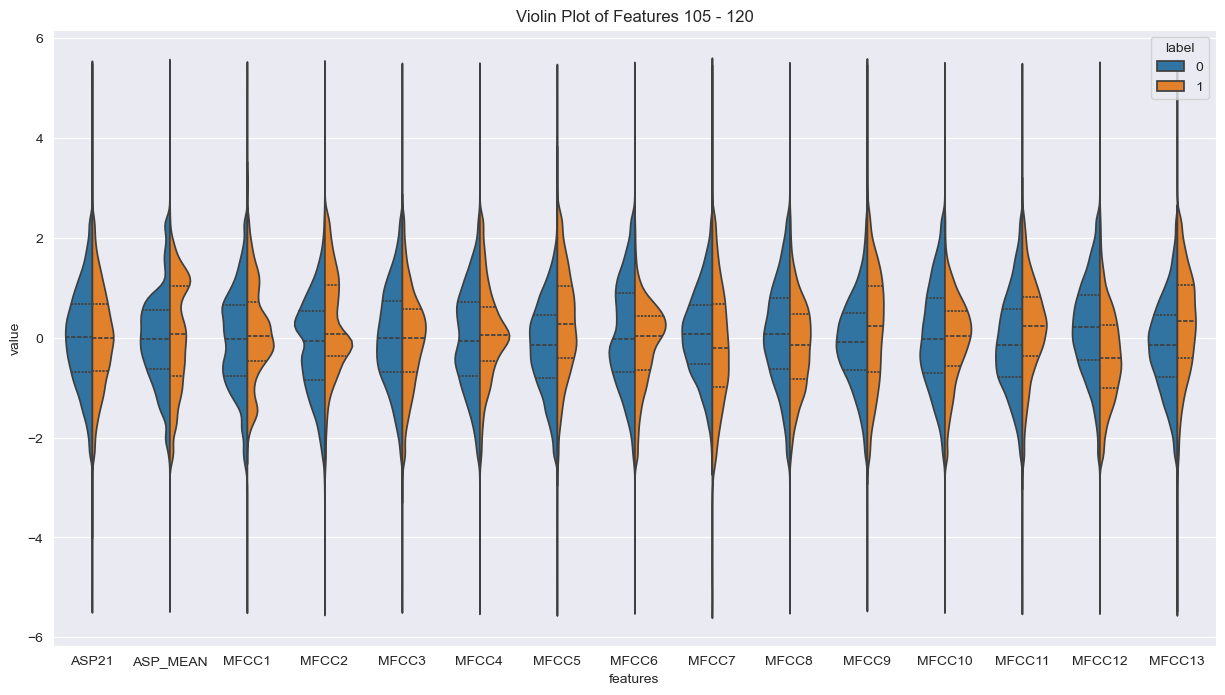

In [52]:

for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.violinplot(x="features", y="value", hue="label", data=data_,
                   split=True, inner="quart")
    plt.title(f"Violin Plot of Features {indexes[i][0]} - {indexes[i][1]}")


Outliers in 60 - 128

### Box plots

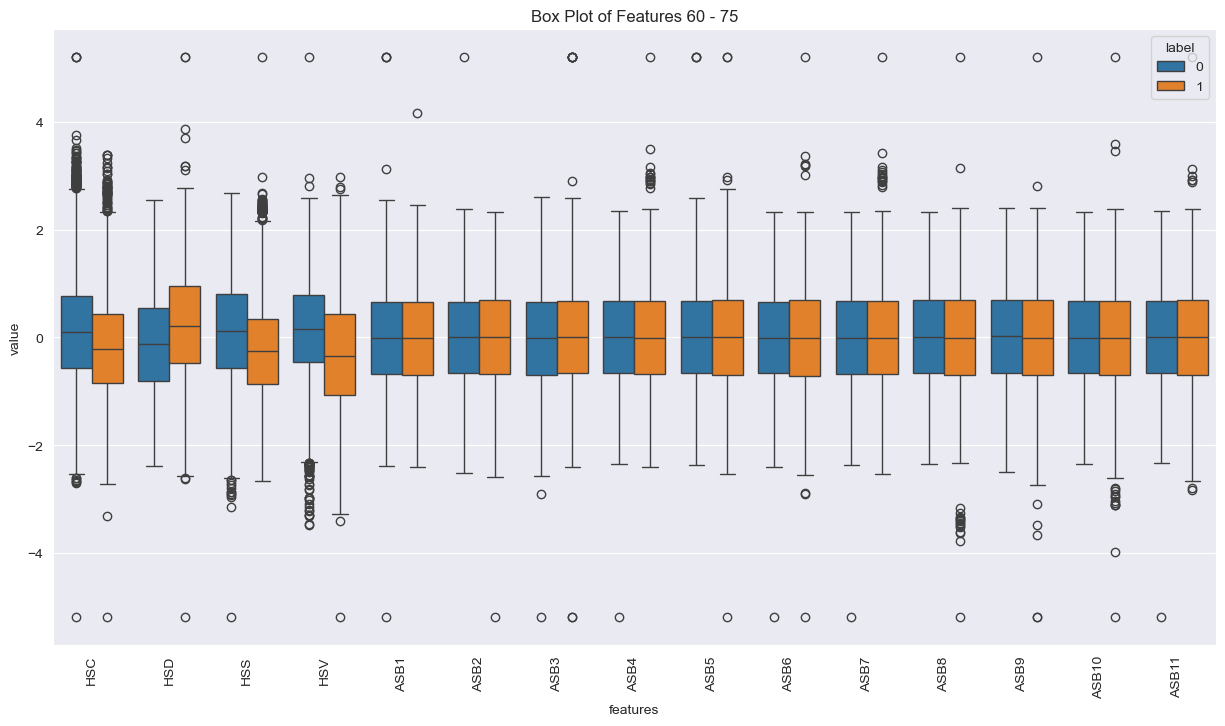

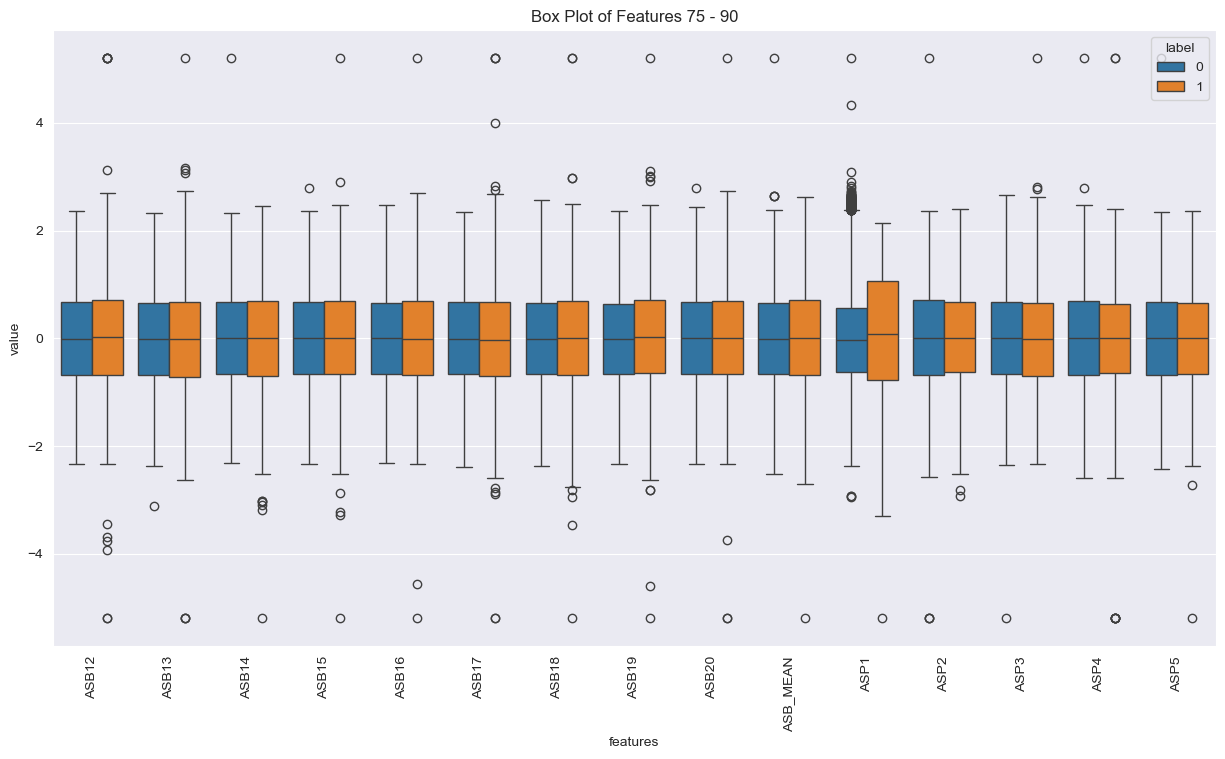

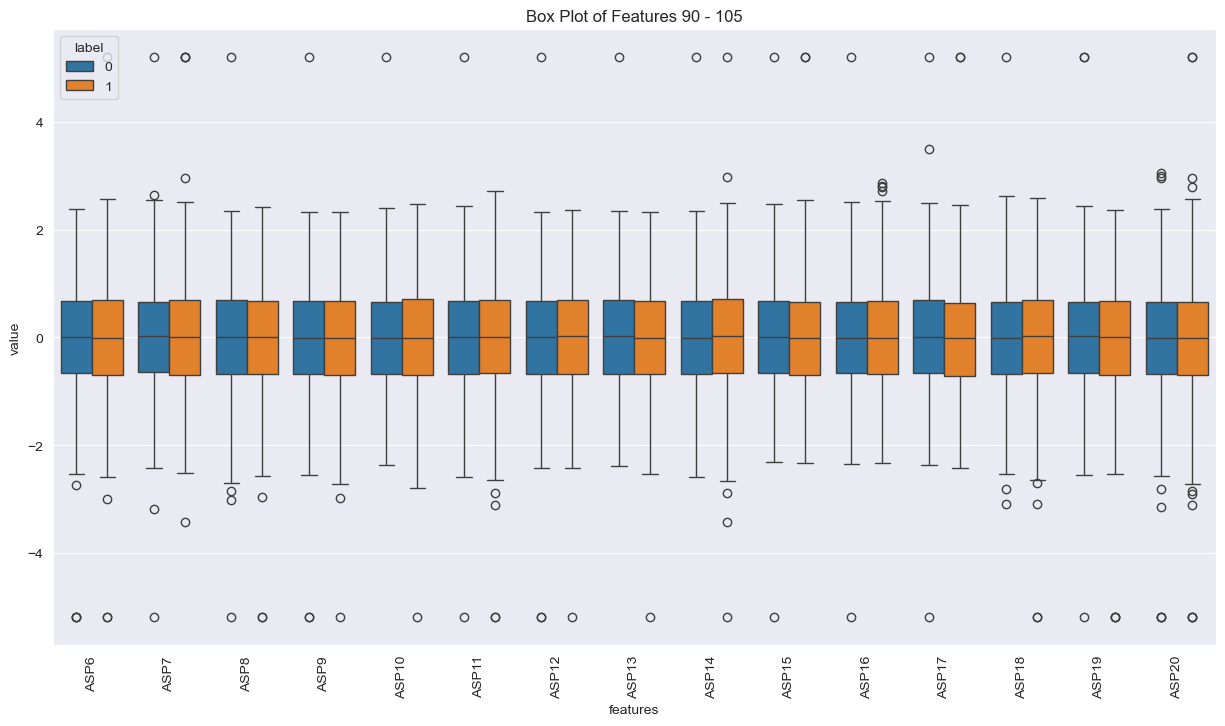

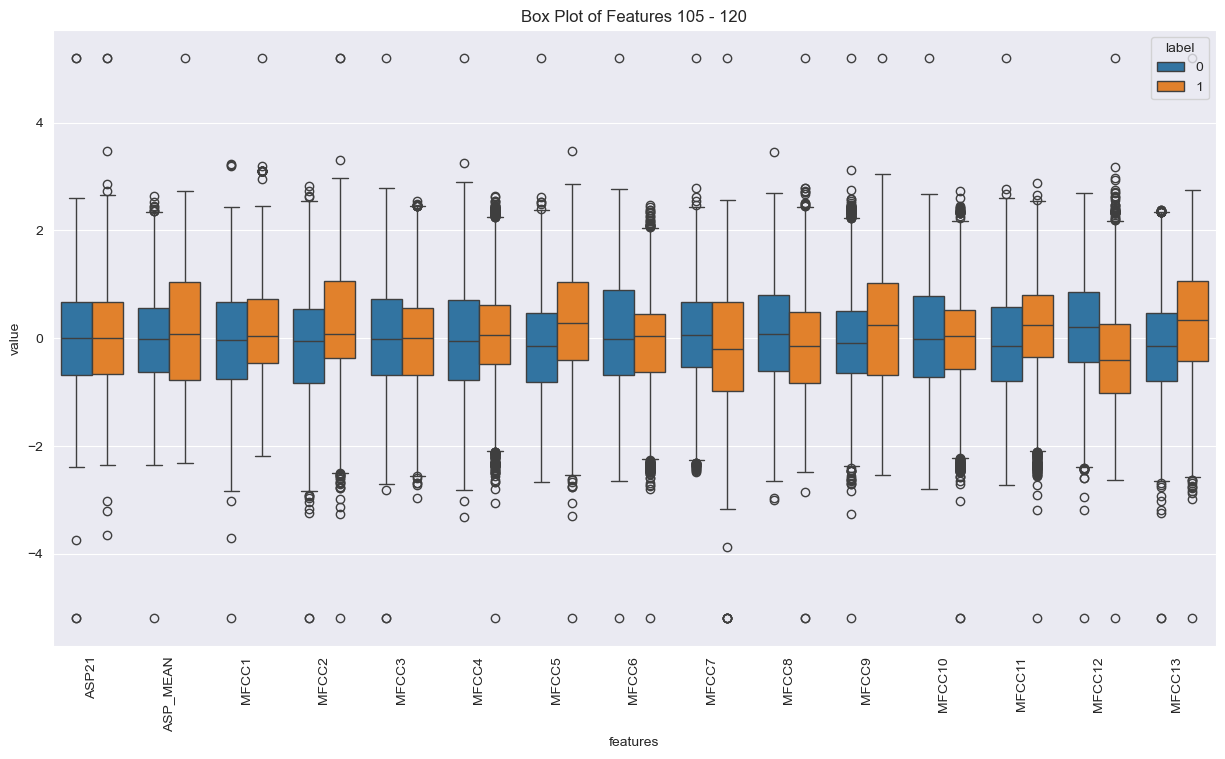

In [53]:
for i in range(4,8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.boxplot(x="features", y="value", hue="label", data=data_)
    plt.xticks(rotation=90)
    plt.title(f"Box Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Strip plots

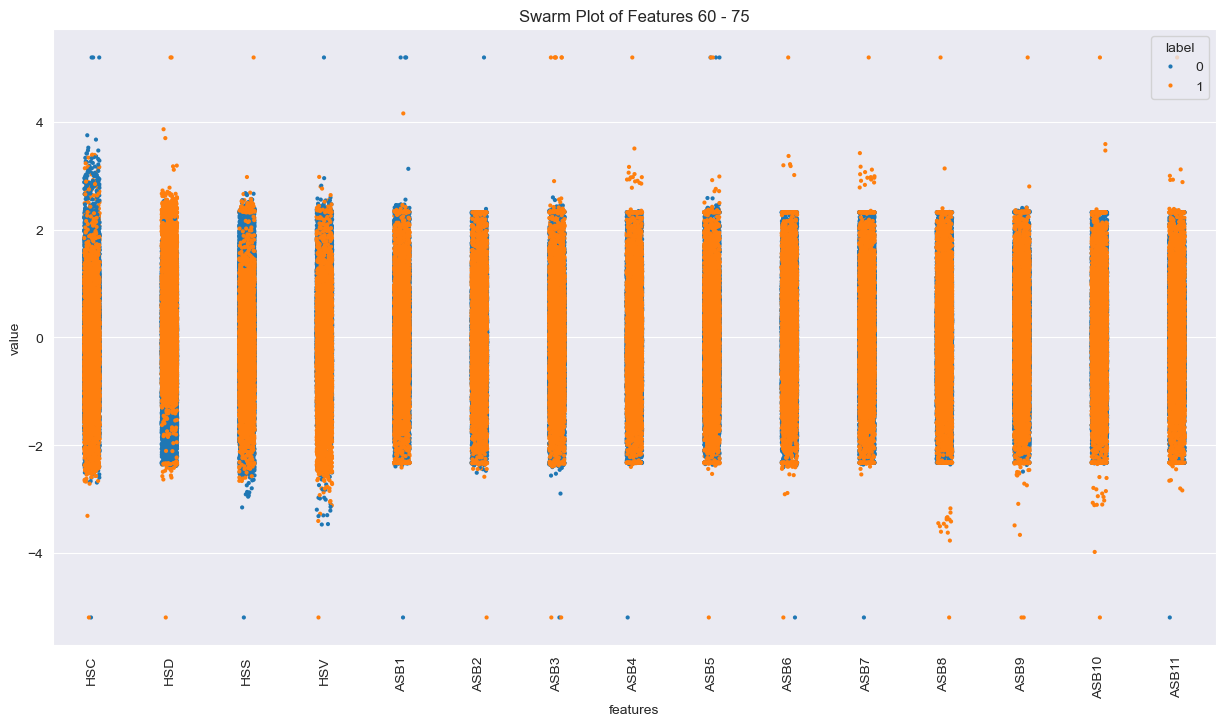

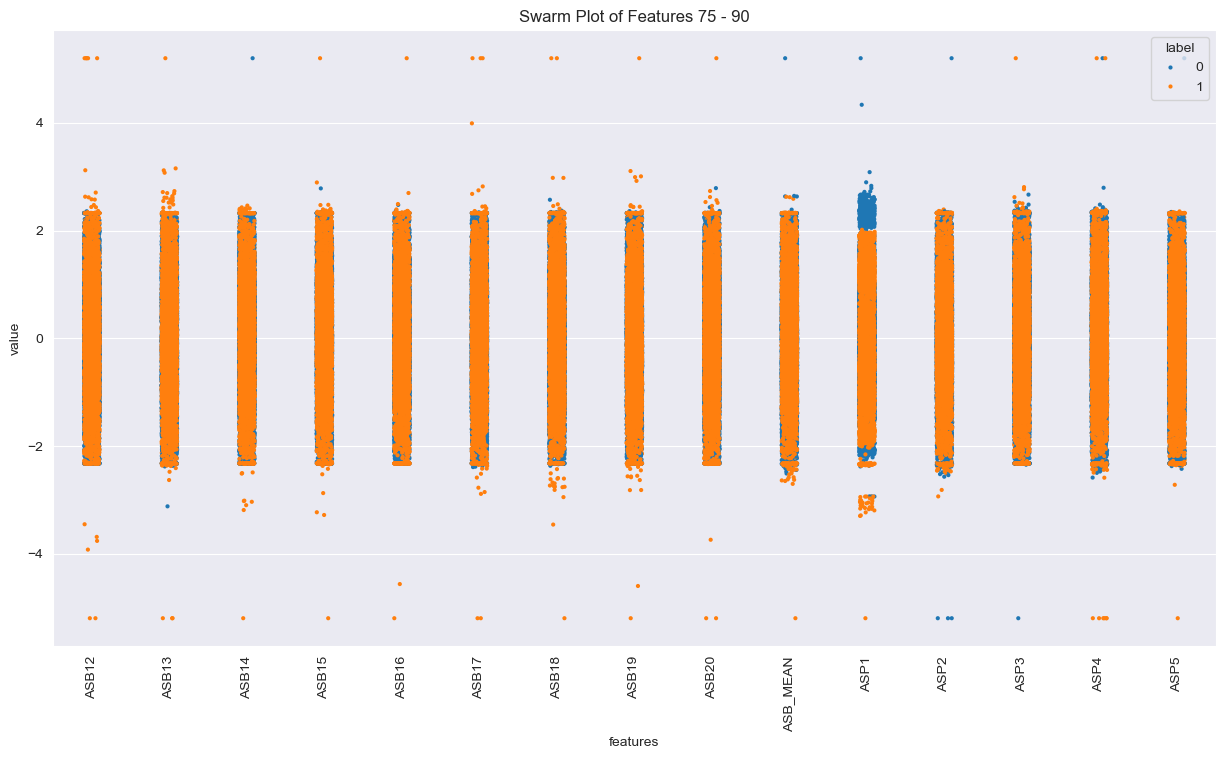

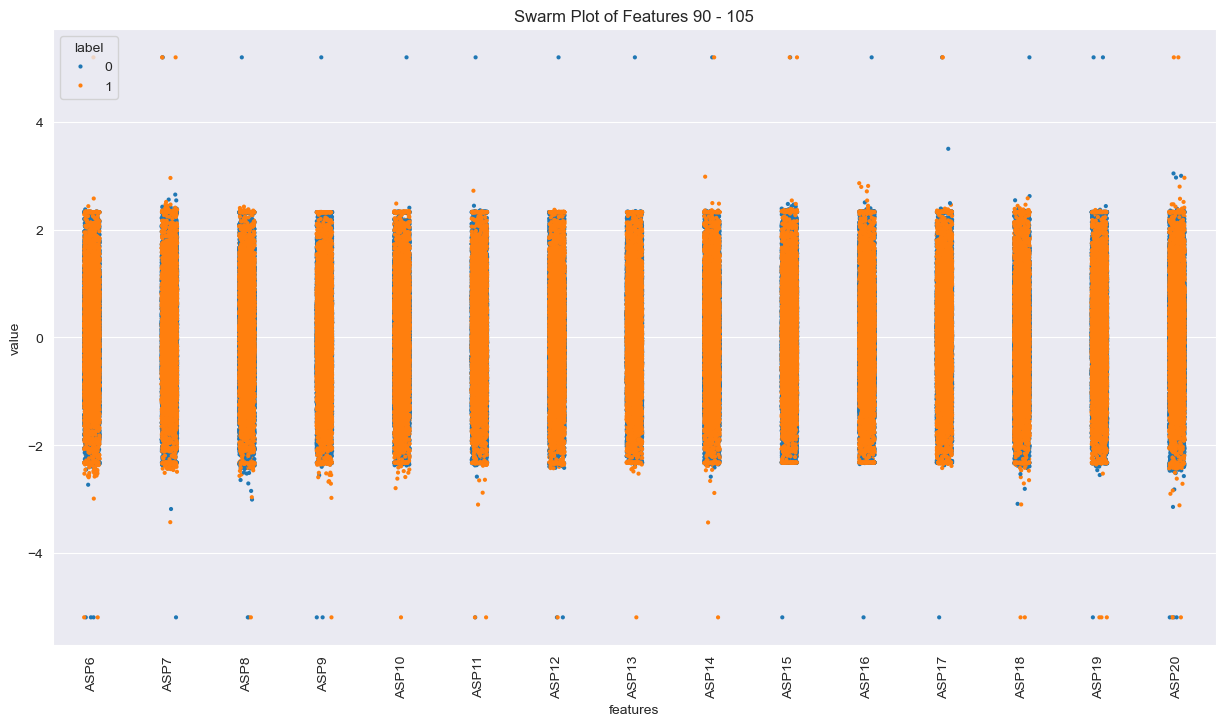

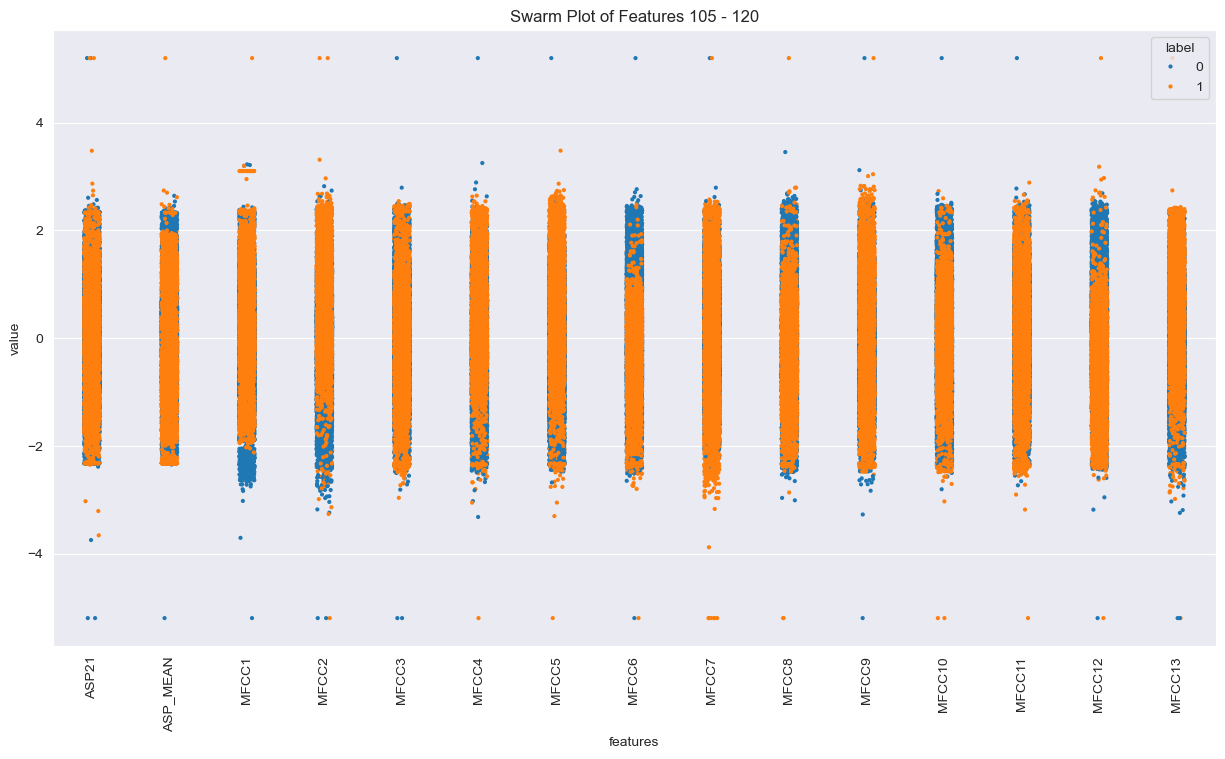

In [54]:
for i in range(4,8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.stripplot(x="features", y="value", hue="label", data=data_, size=3)
    plt.xticks(rotation=90)
    plt.title(f"Swarm Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Swarm plot of random 2000 Samples

c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 84.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 85.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 81.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 82.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-

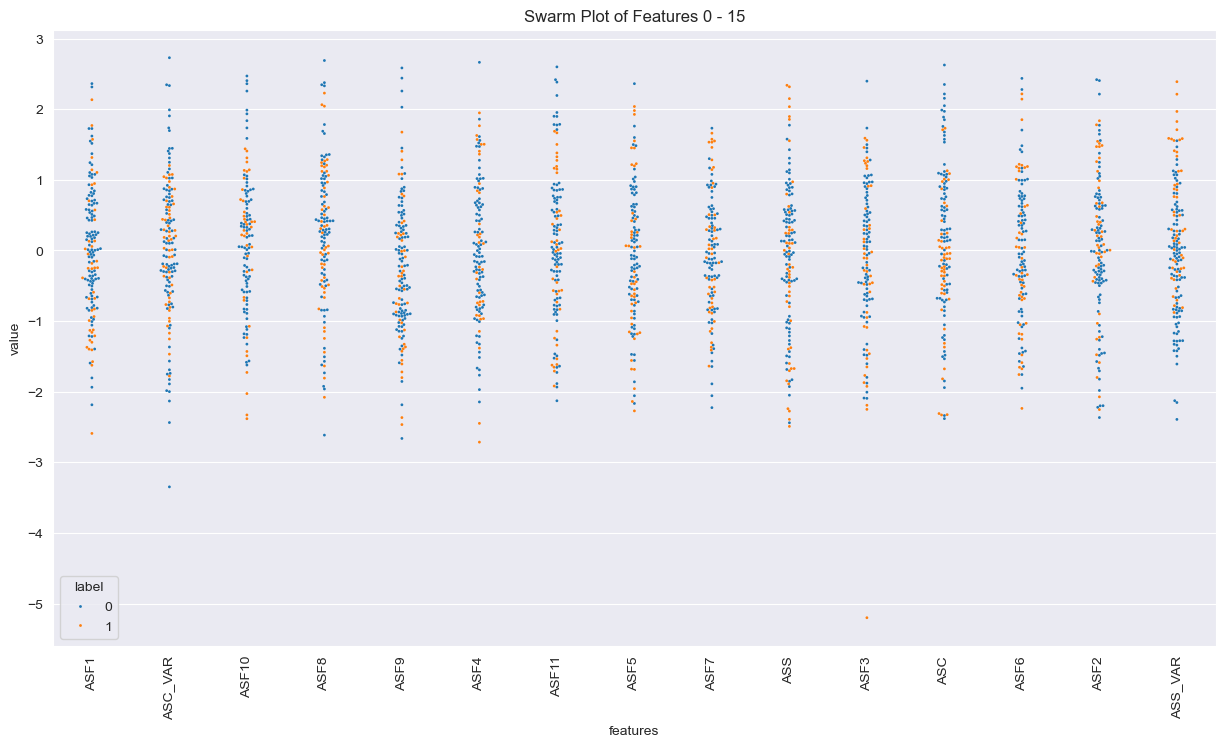

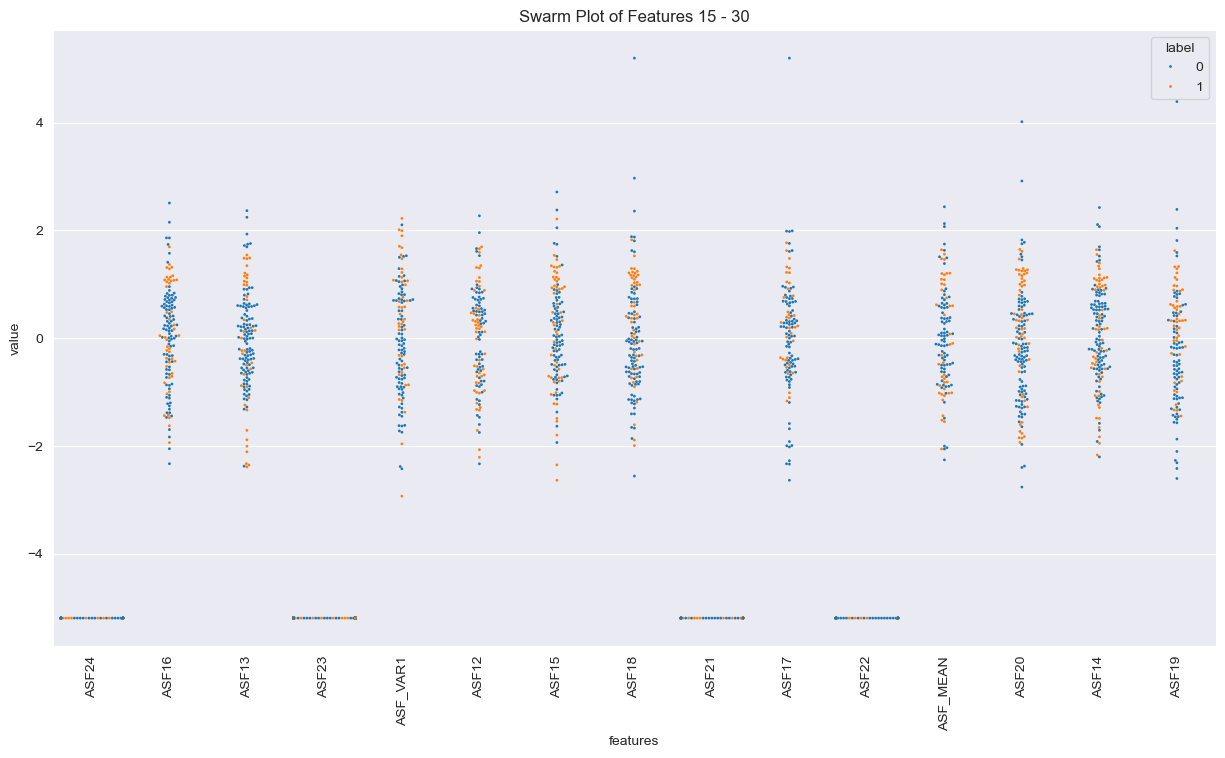

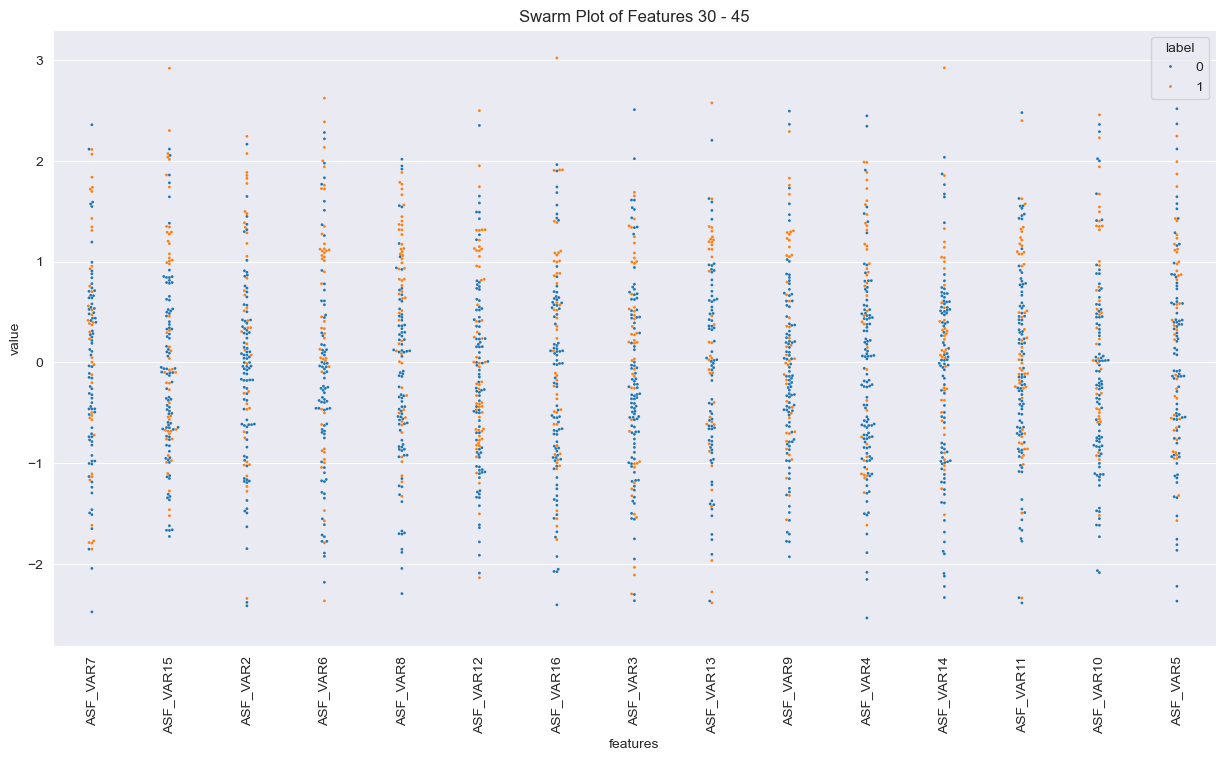

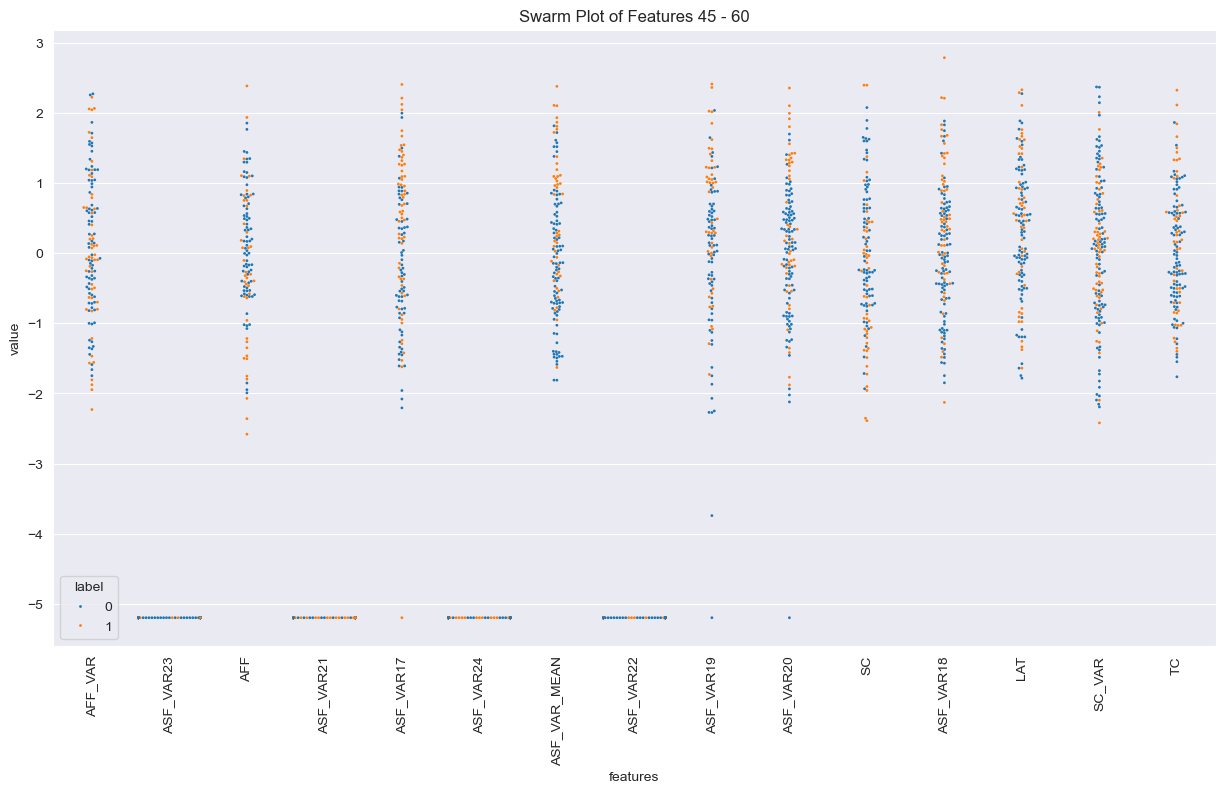

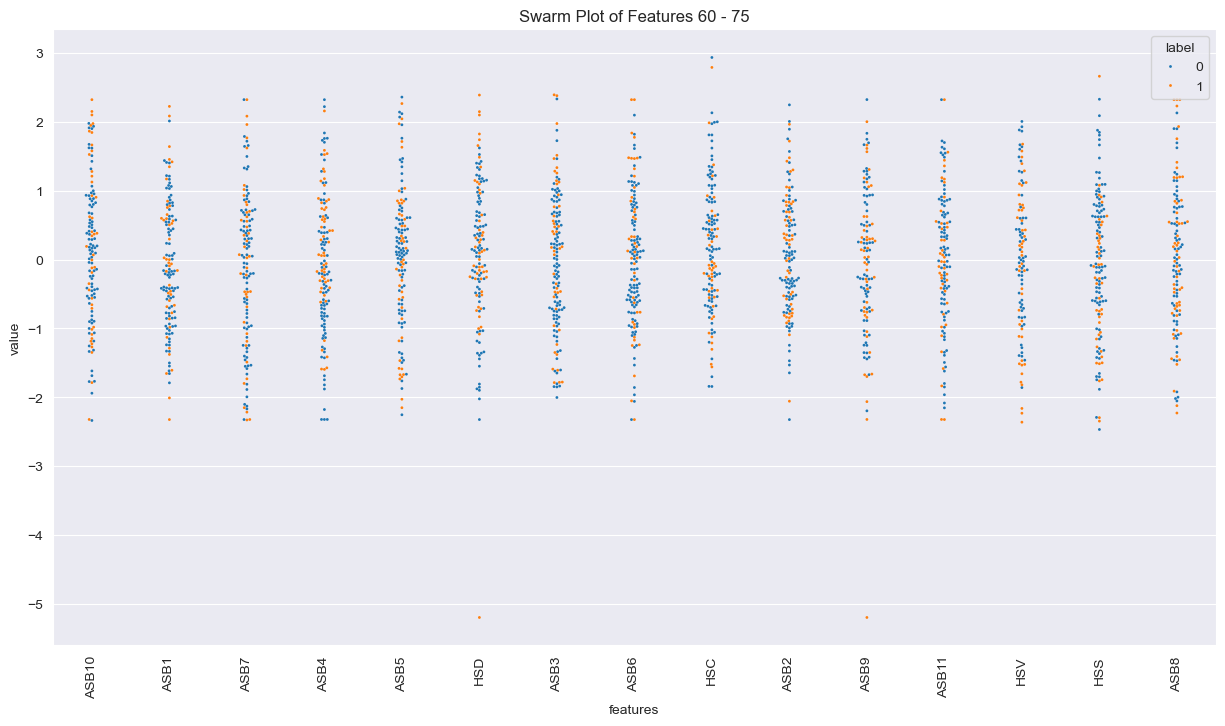

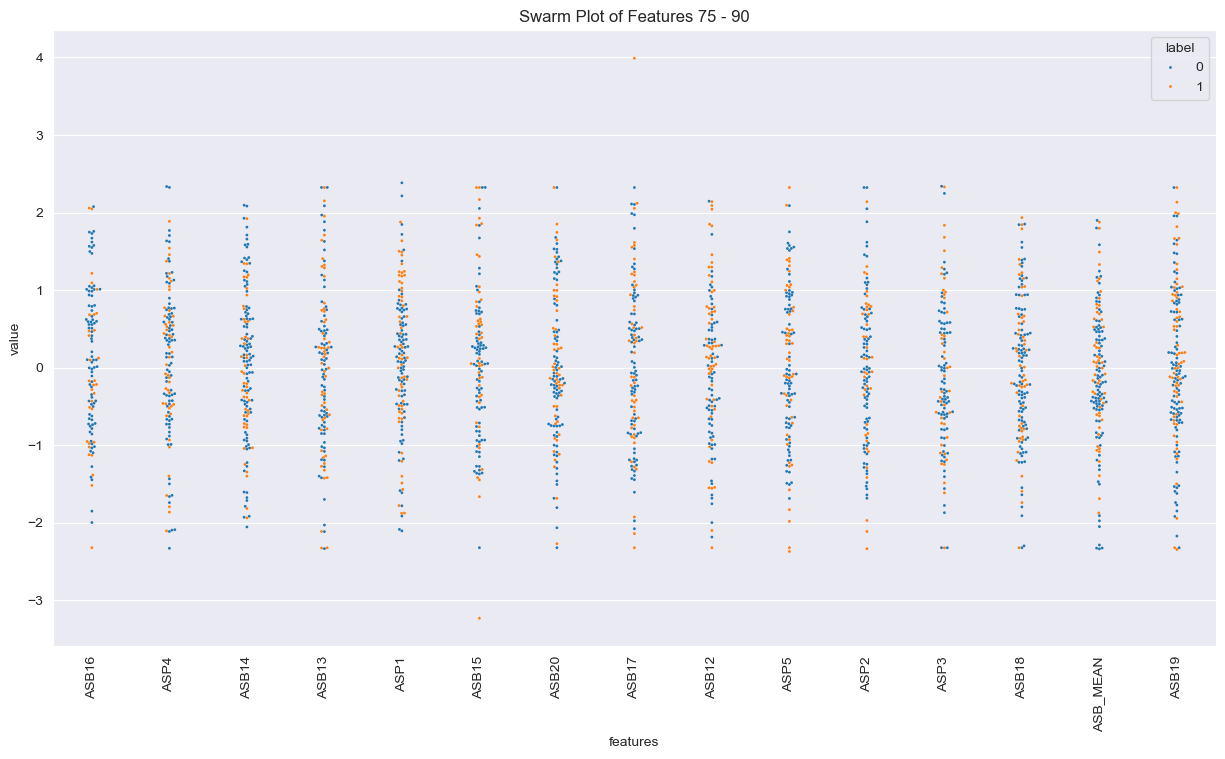

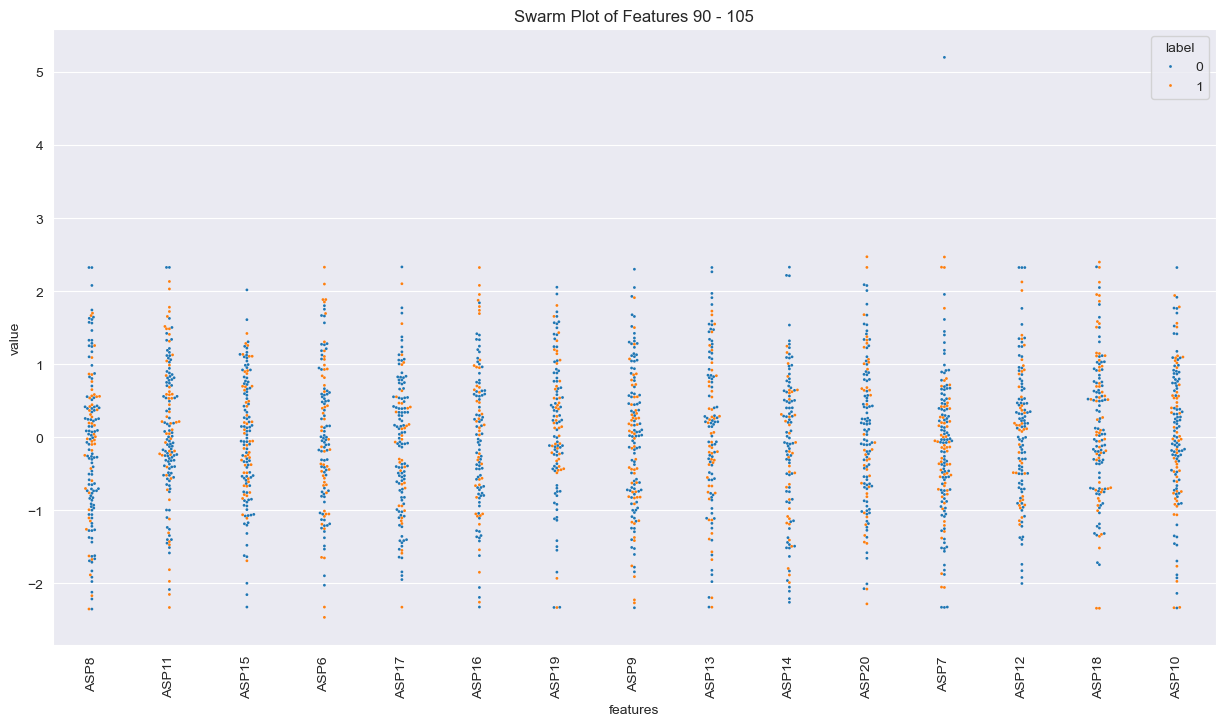

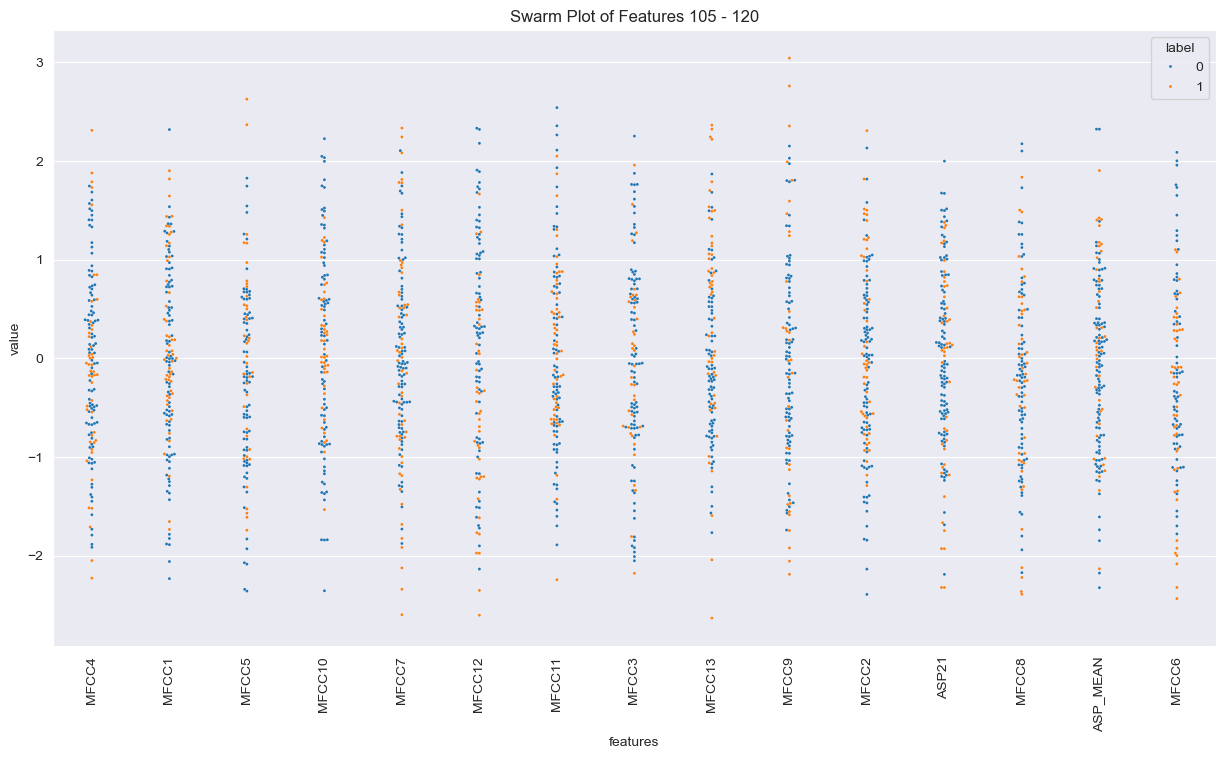

In [55]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    data_sample = data_.sample(2000)
    sns.swarmplot(x="features", y="value", hue="label", data=data_sample, size=2)
    plt.xticks(rotation=90)
    plt.title(f"Swarm Plot of Features {indexes[i][0]} - {indexes[i][1]}")


## Z score

In [108]:
from scipy.stats import norm
def remove_z_outliers(df, features, threshold=4, label_col='label') -> pd.DataFrame:
    valid_features = [f for f in features if np.issubdtype(df[f].dtype, np.number) and df[f].std() > 0]
    if not valid_features:
        print("No valid features for outlier removal.")
        return df[[label_col]]
    z_scores = np.abs((df[valid_features] - df[valid_features].mean()) / df[valid_features].std())
    mask = (z_scores < threshold).all(axis=1)
    print(f"z-score of {threshold} corresponds to a prob of {100 * 2 * norm.sf(threshold):.6f}%")
    print(f"Rejected {(~mask).sum()} points (any feature)")
    return df.loc[mask]


### Scaling data before detecting outliers

In [169]:
data_iqr = parametrized_data.copy() 
y = data_iqr['label']
X = data_iqr.drop('label', axis=1)
scaler_outliers = StandardScaler()
data_iqr = scaler_outliers.fit_transform(X)

In [170]:
features = list(X.columns)

data_iqr = pd.concat([y, pd.DataFrame(data_iqr, columns=parametrized_data.columns[1:])], axis=1)
data_cleaned = remove_z_outliers(data_iqr, features, threshold=4)
data_cleaned = data_cleaned.reset_index(drop = True)
data_cleaned.isna().sum().sum()


z-score of 4 corresponds to a prob of 0.006334%
Rejected 1940 points (any feature)


np.int64(0)

## Detecting outliers with IQR

In [59]:
def iqr_capping(df, cols, factor):
    
    for col in cols:
        
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        
        iqr = q3 - q1
        
        upper_whisker = q3 + (factor*iqr)
        lower_whisker = q1 - (factor*iqr)
        
        df[col] = np.where(df[col]>upper_whisker, upper_whisker,
                 np.where(df[col]<lower_whisker, lower_whisker, df[col]))

In [60]:
# iqr_capping(data_cleaned, features, 1.5)

### Separating data again

In [62]:
# from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler,  MaxAbsScaler, PowerTransformer,QuantileTransformer
# scaler = QuantileTransformer(n_quantiles=100, output_distribution='normal')
# X_clipped = data_cleaned.drop(columns=['label'])
# scaler = StandardScaler()
# X_clipped = scaler.fit_transform(X_clipped)
# data_clipped = pd.DataFrame(X_clipped, columns=parametrized_data.columns[1:])

In [164]:
y = data_cleaned['label']
X = data_cleaned.drop('label', axis=1)

### Violin plot

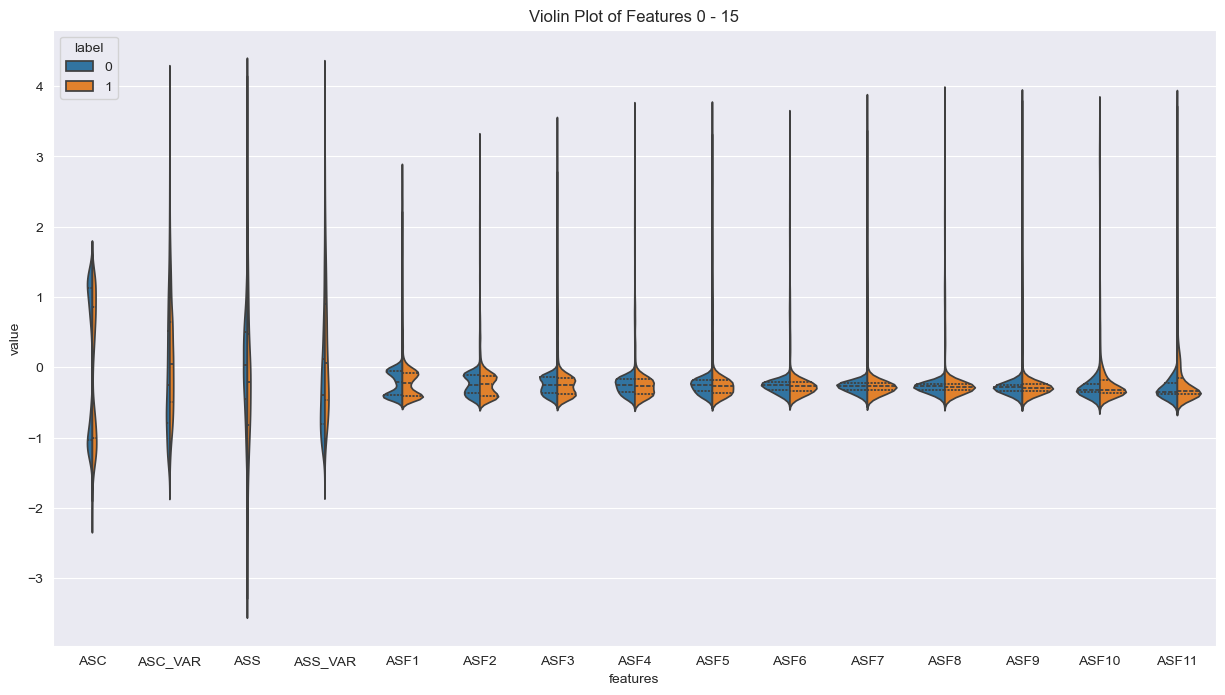

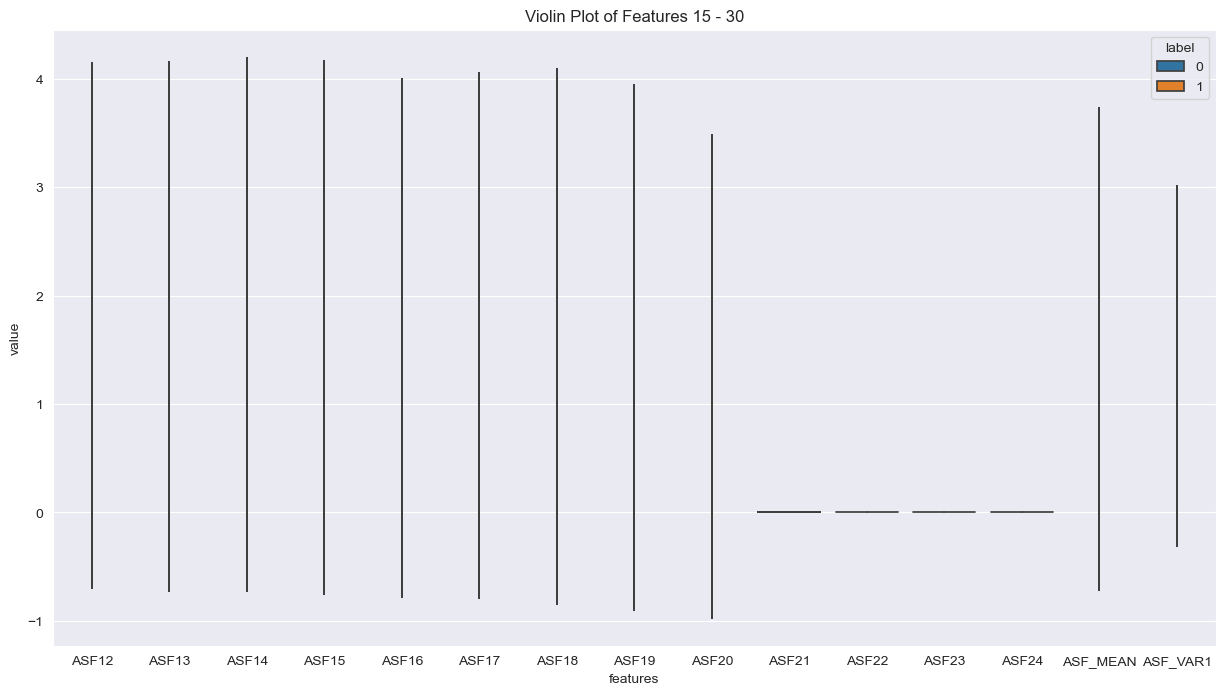

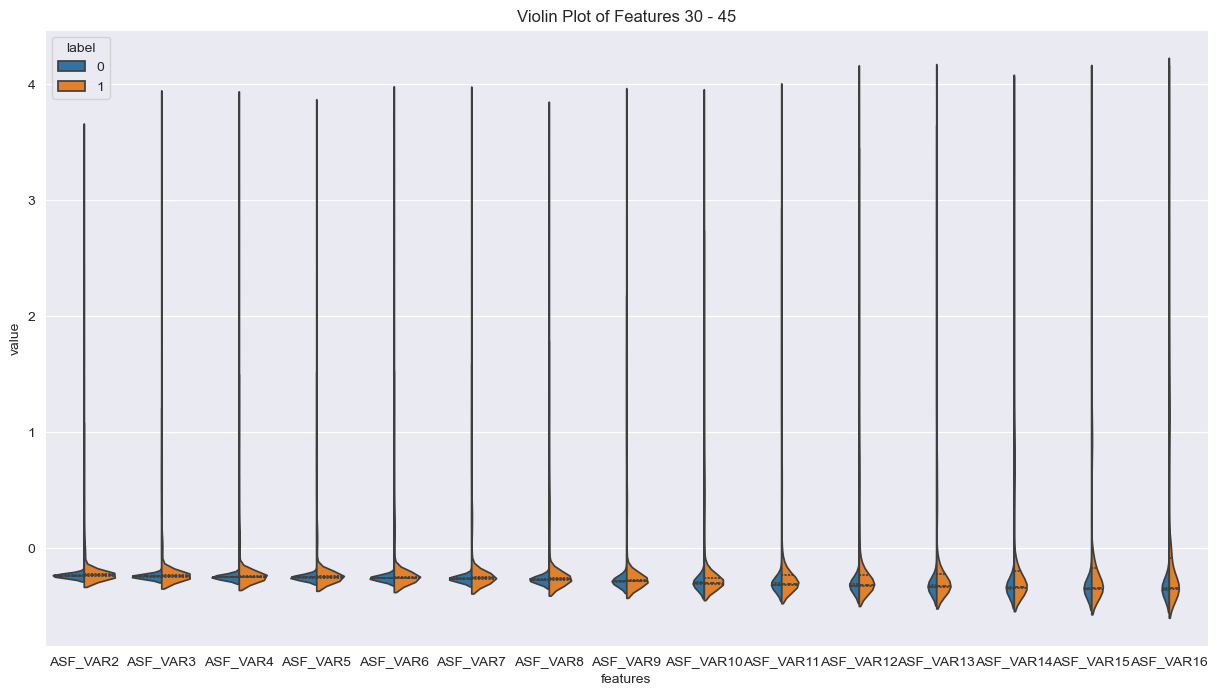

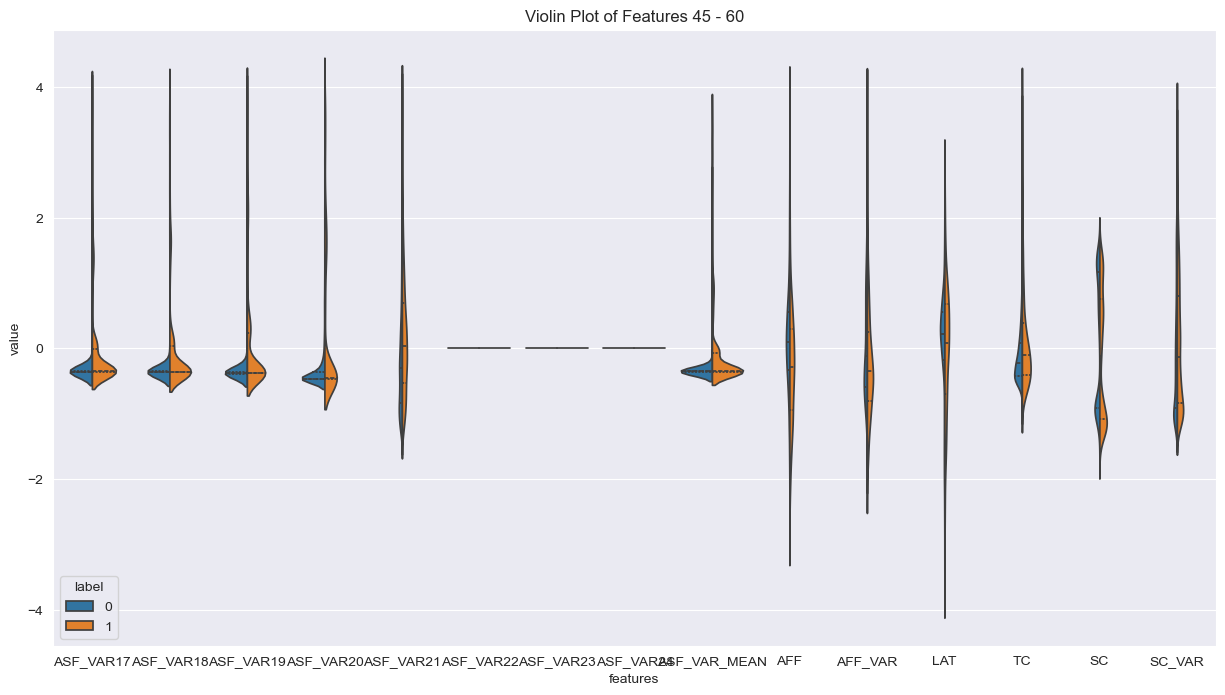

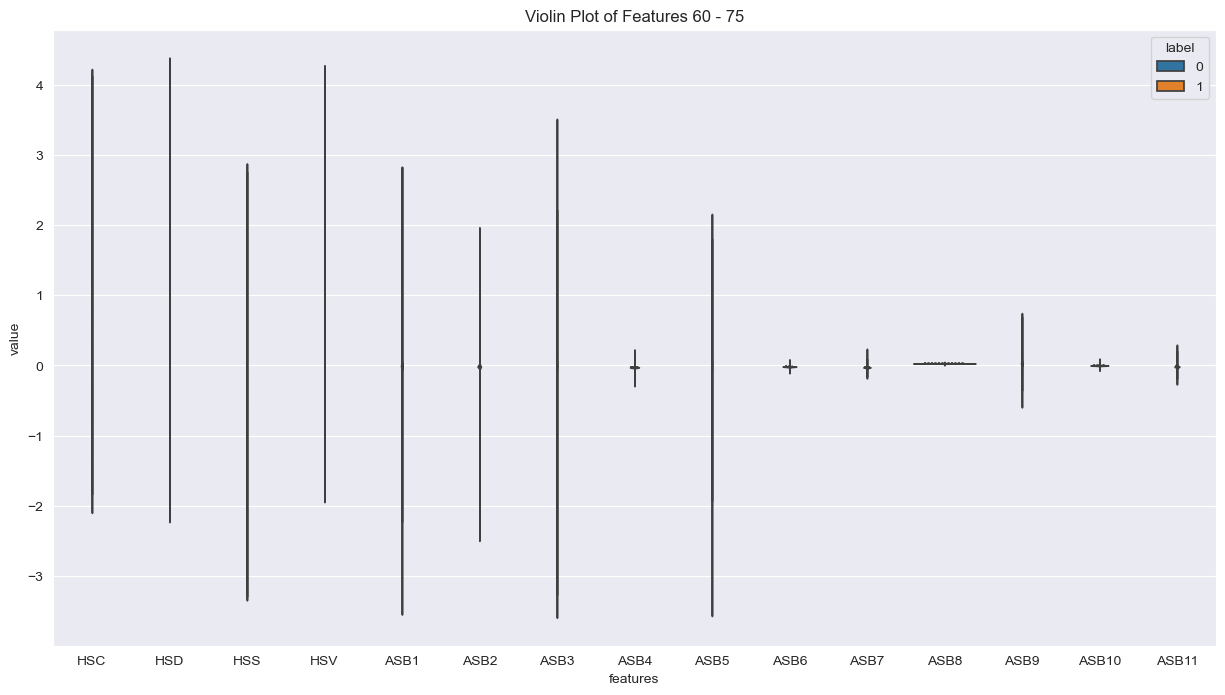

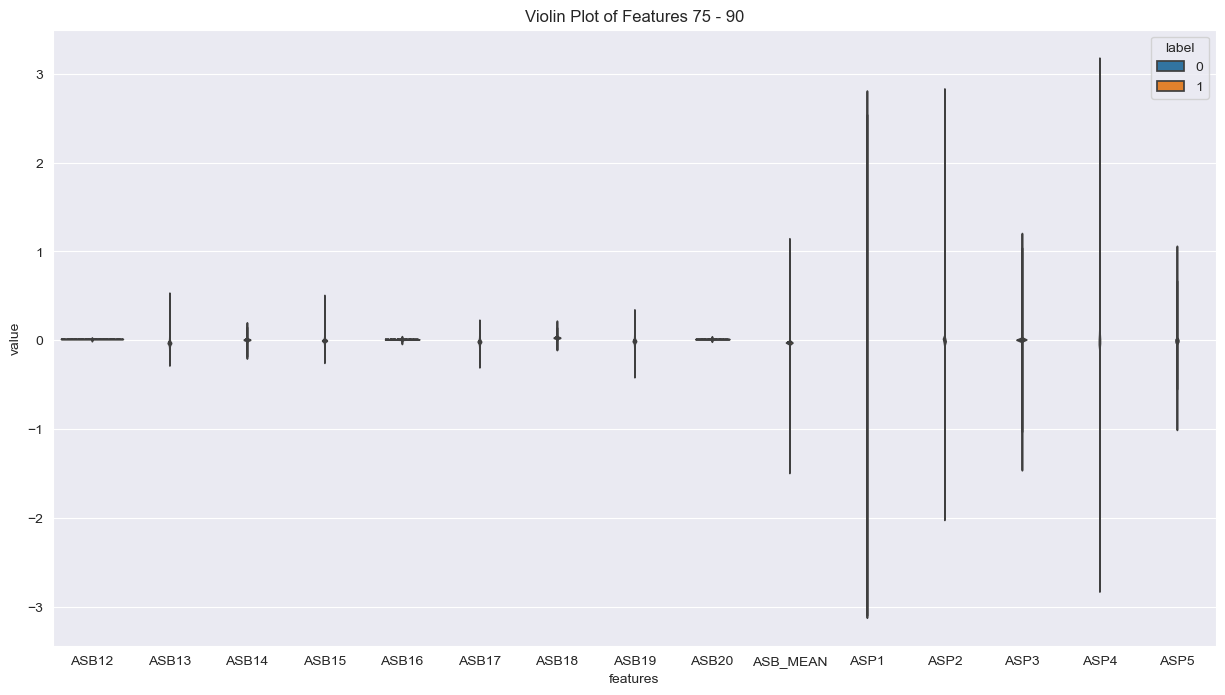

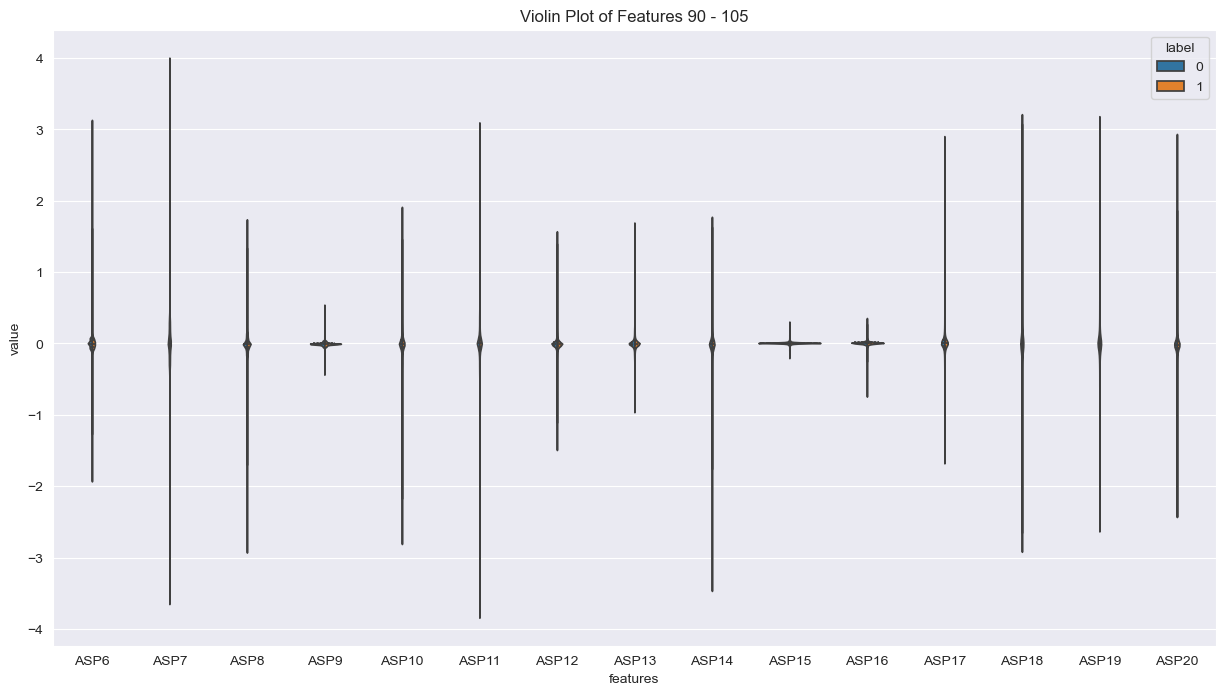

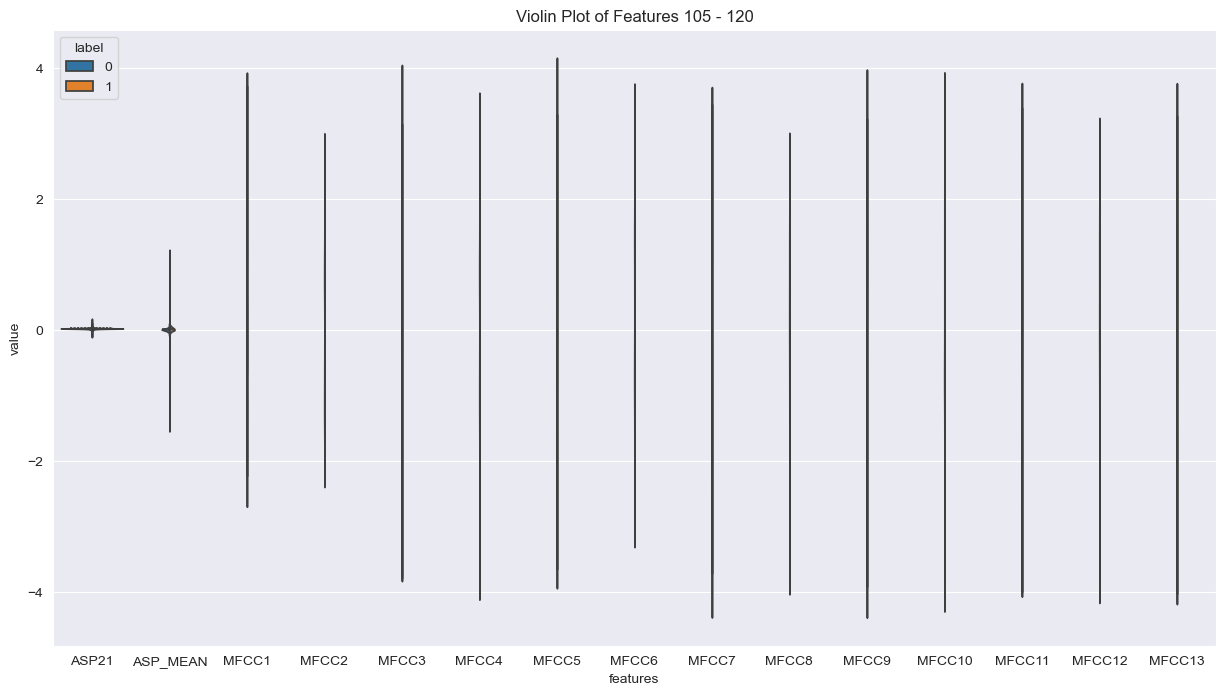

In [64]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, X.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.violinplot(x="features", y="value", hue="label", data=data_,
                   split=True, inner="quart")
    plt.title(f"Violin Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Box plots of clipped data

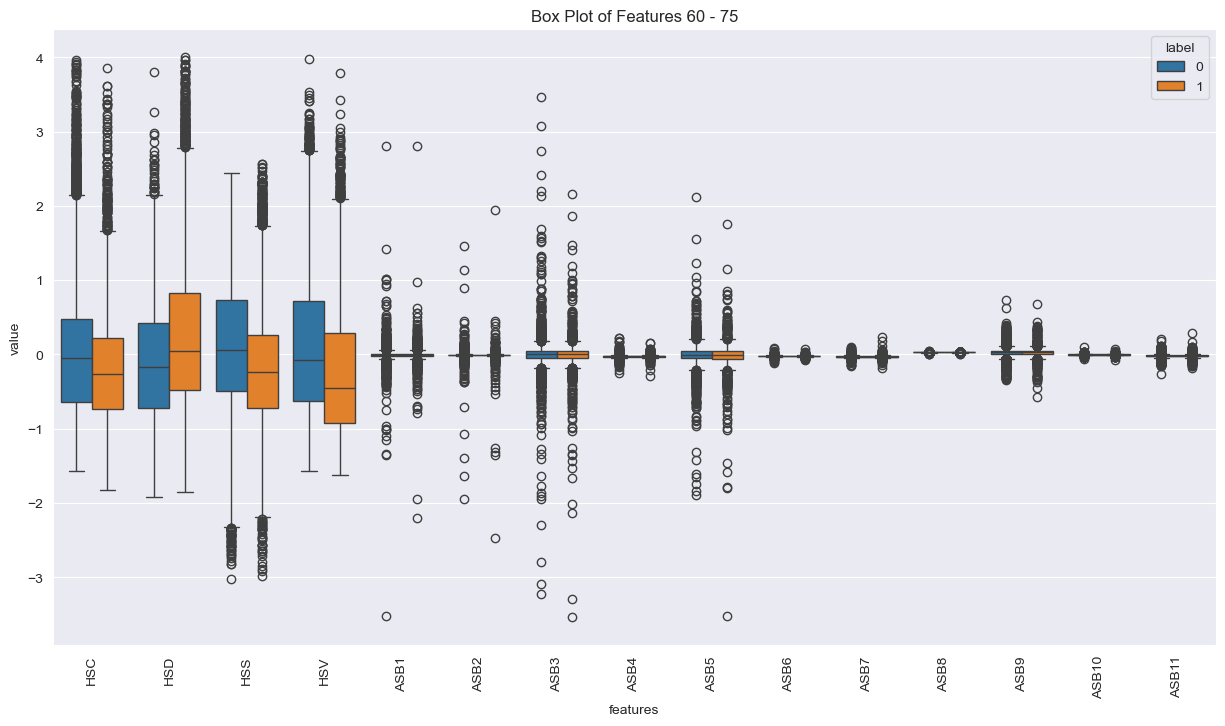

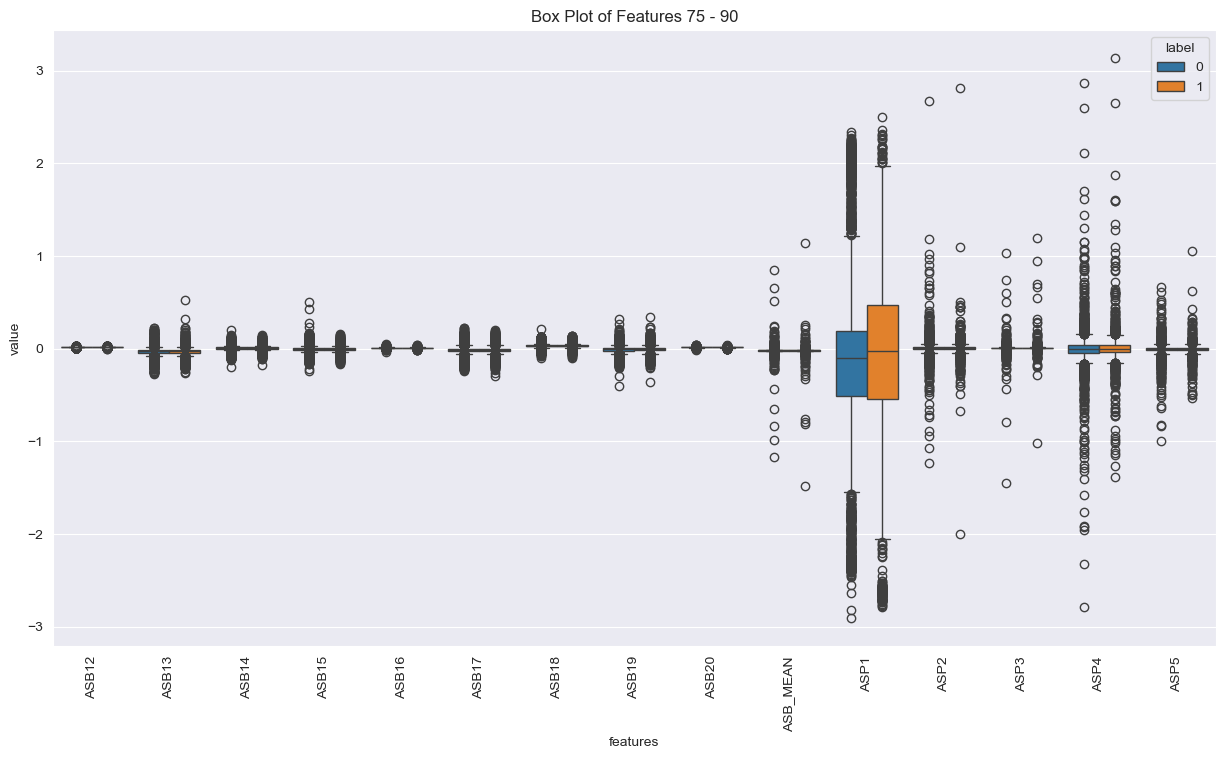

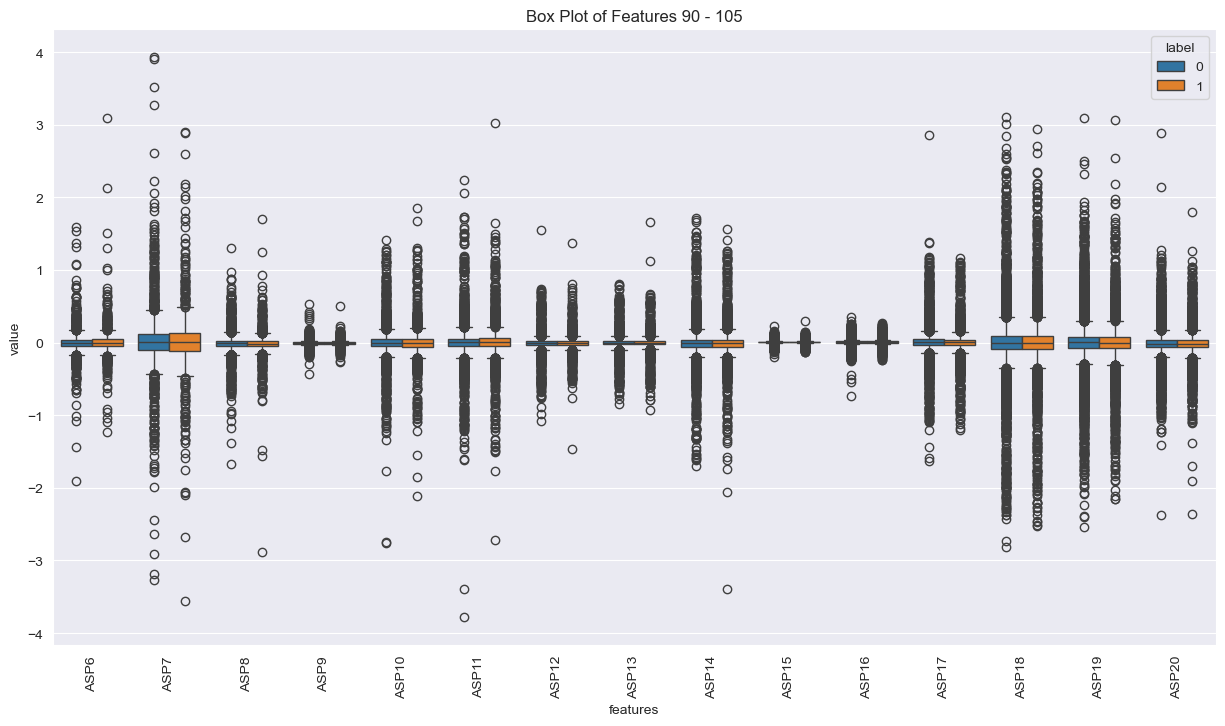

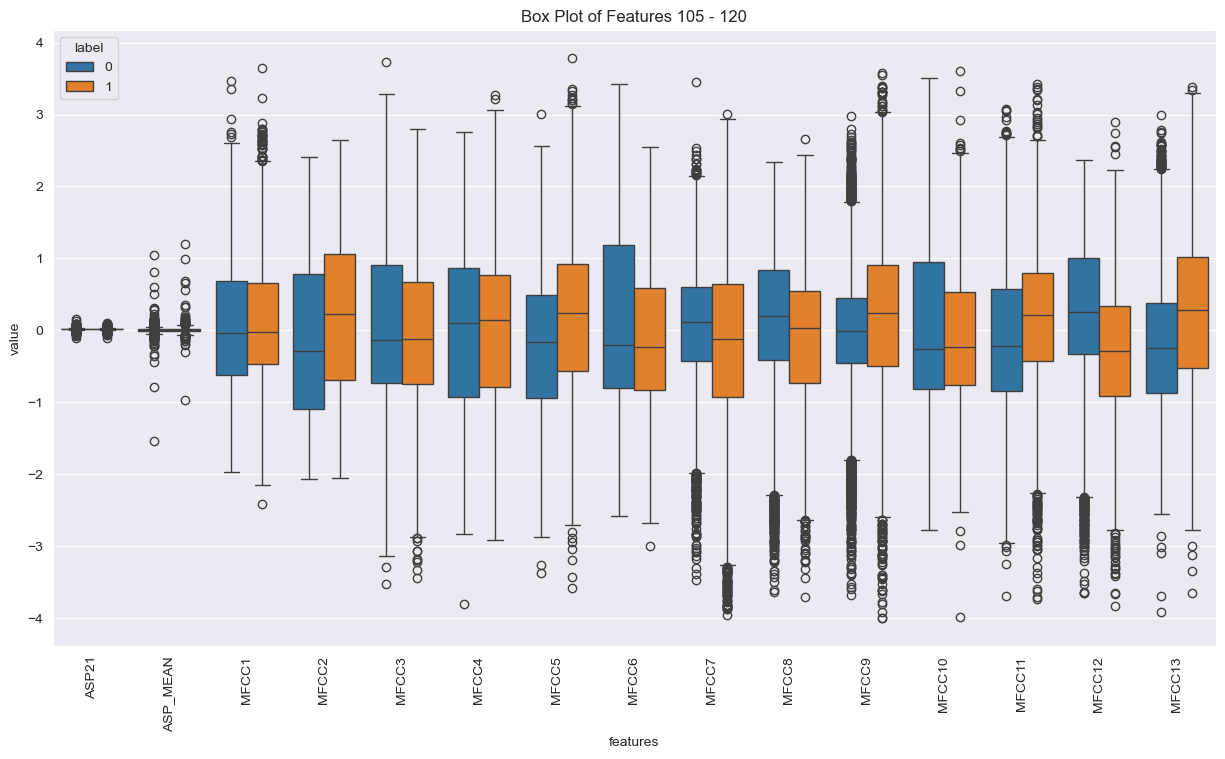

In [65]:
for i in range(4,8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, X.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.boxplot(x="features", y="value", hue="label", data=data_)
    plt.xticks(rotation=90)
    plt.title(f"Box Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Removing outliers with Isolation Forest

In [165]:
from sklearn.ensemble import IsolationForest

X = scaler_outliers.inverse_transform(X)
isolation_forest = IsolationForest(random_state=42 ,n_jobs=-1)
isolation_forest.fit(X,y)
predictions = isolation_forest.predict(X)
print("Predictions: \n", predictions[:20])
print("Outlier count: \n", len(predictions[predictions == -1]))
print("Inlier count: \n", len(predictions[predictions == 1]))
decision_scores = isolation_forest.decision_function(X)
print("Decision scores: \n", decision_scores[:20])
print("Decision scores shape:", decision_scores.shape)
decision_scores_df = pd.DataFrame(decision_scores, columns=['decision_scores'])
decision_scores_df.sort_values(by='decision_scores', ascending=False, inplace=True)
decision_scores_df.head()


Predictions: 
 [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1]
Outlier count: 
 892
Inlier count: 
 14795
Decision scores: 
 [ 0.08109877  0.1038315   0.10340212  0.14846244  0.11840891  0.13308649
  0.13650218  0.13324345  0.13969451  0.13780937  0.13488399  0.13739807
  0.13879006  0.12500164  0.1369509   0.11857748  0.14913854  0.10458789
 -0.02461274  0.11047597]
Decision scores shape: (15687,)


,decision_scores
1317,0.164067
6864,0.162846
8883,0.161771
2351,0.161717
8786,0.161557


In [166]:
X_clipped = X[np.where(predictions == 1, True, False)]
y_clipped = y[np.where(predictions == 1,True, False)]
data_clipped= pd.DataFrame(X_clipped, columns=parametrized_data.columns[1:])
len(y_clipped)
# len(X_clipped)

14795

### Box plots of data after Forest Isolation

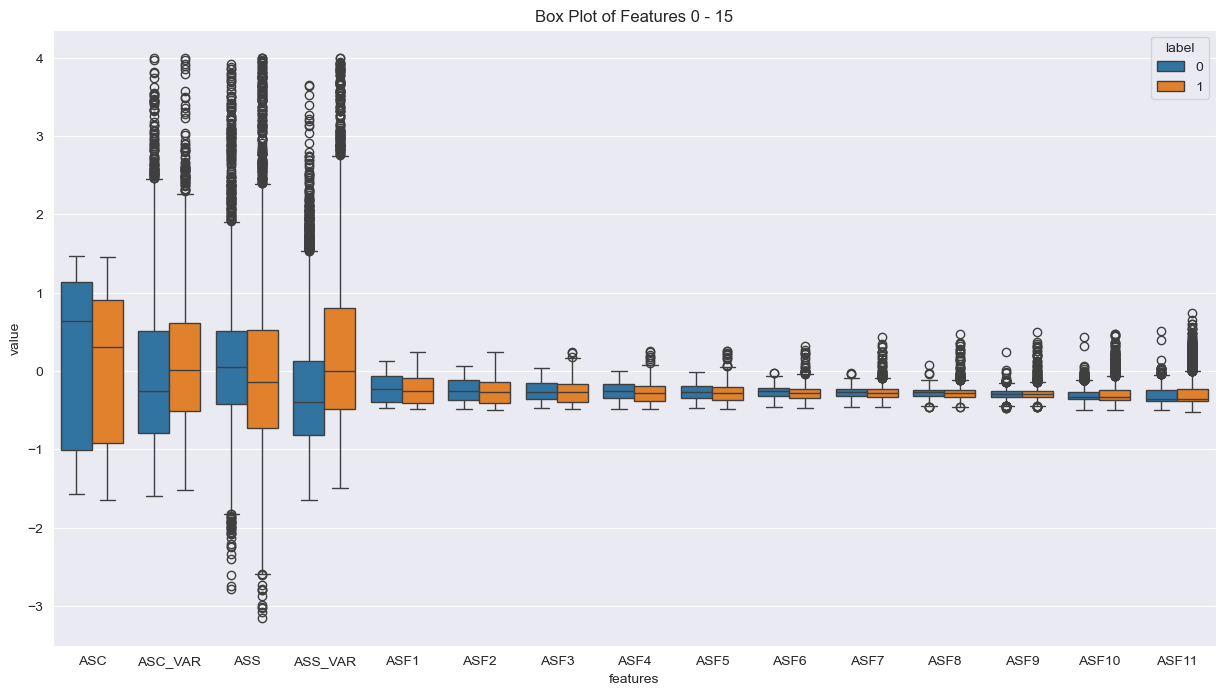

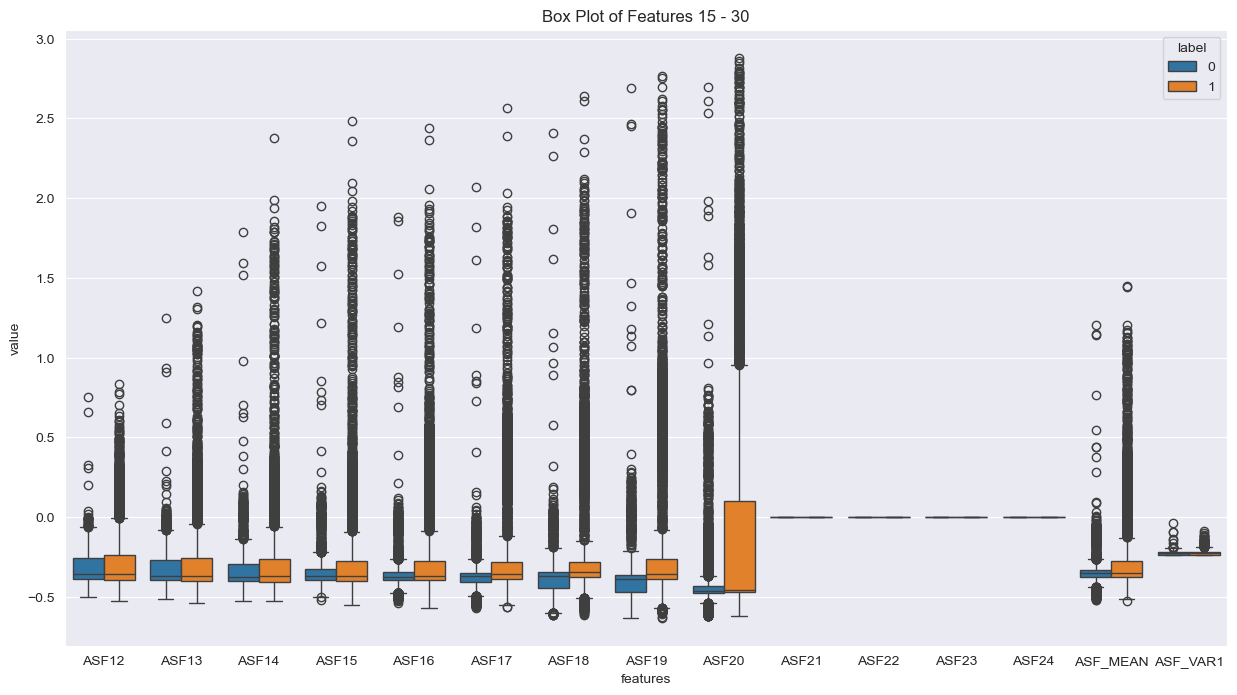

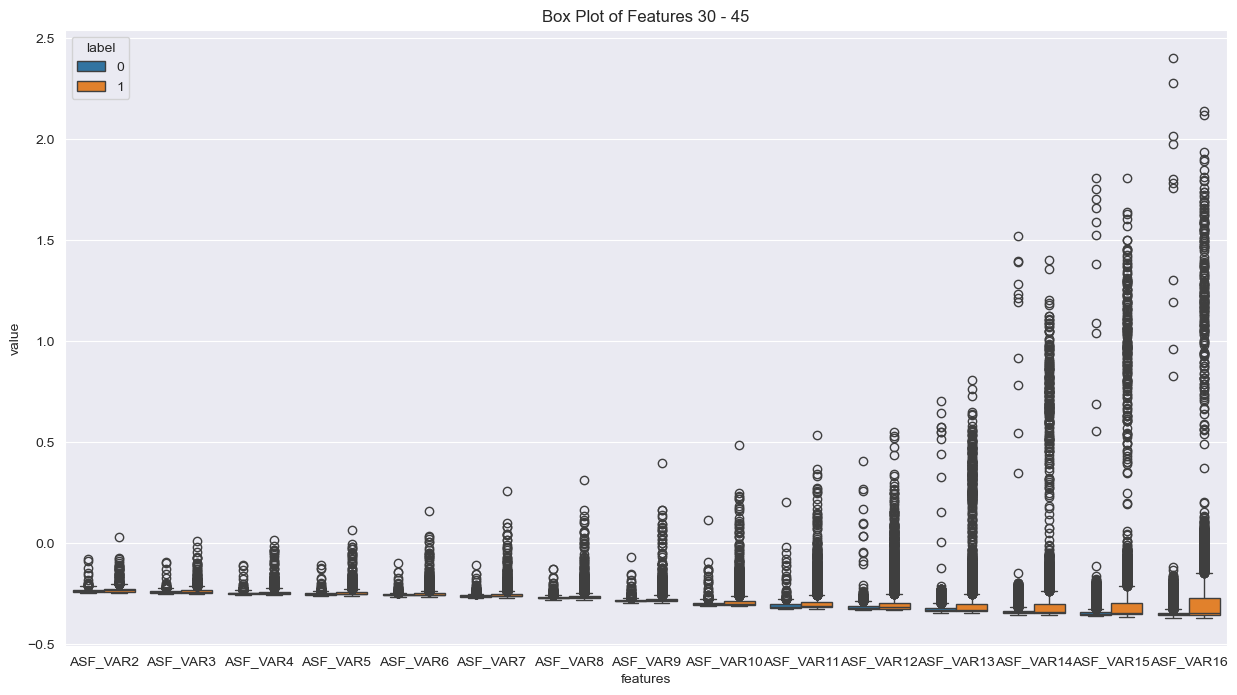

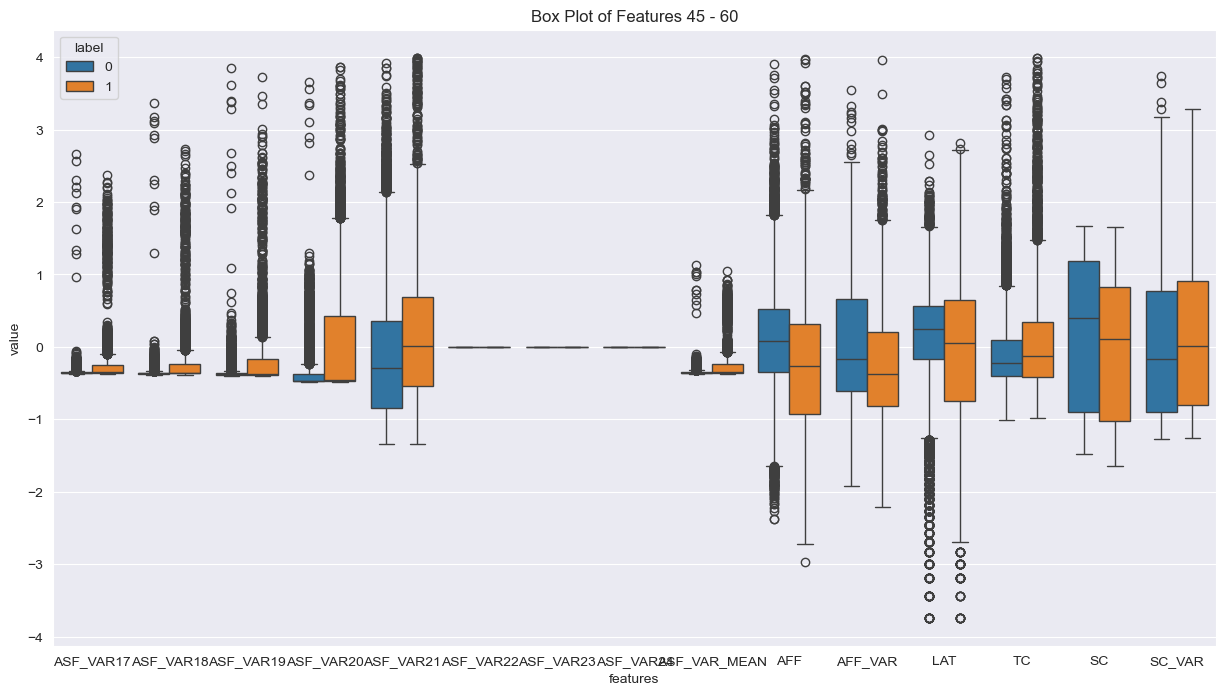

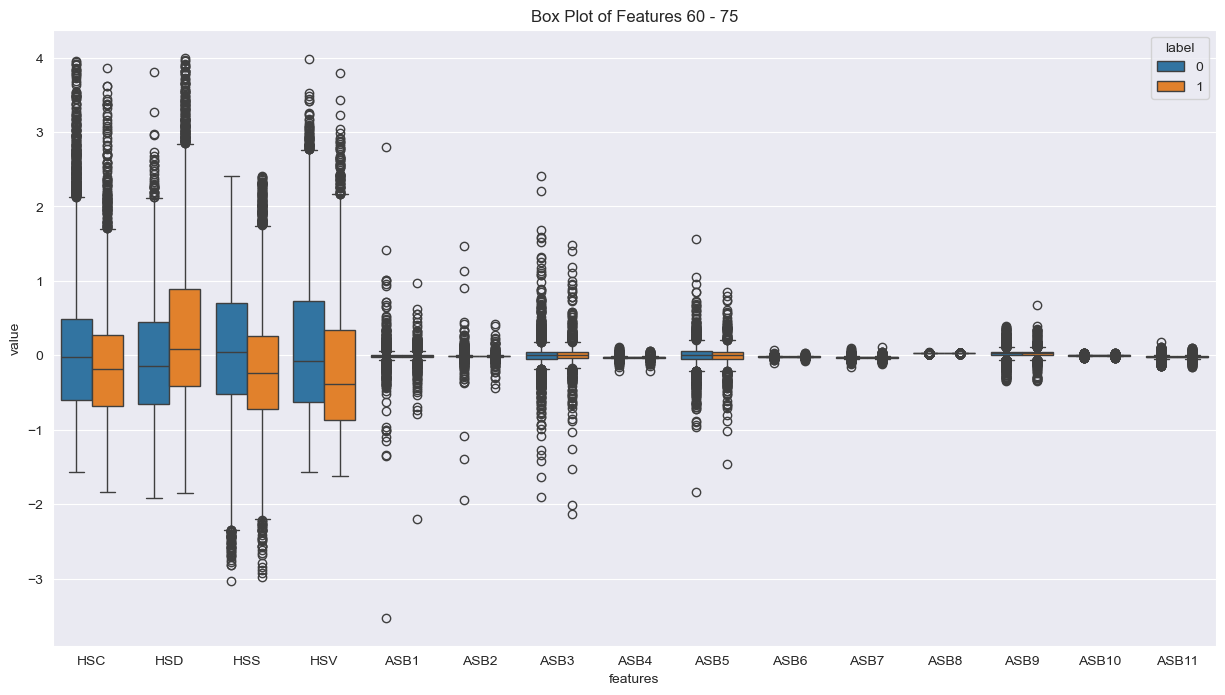

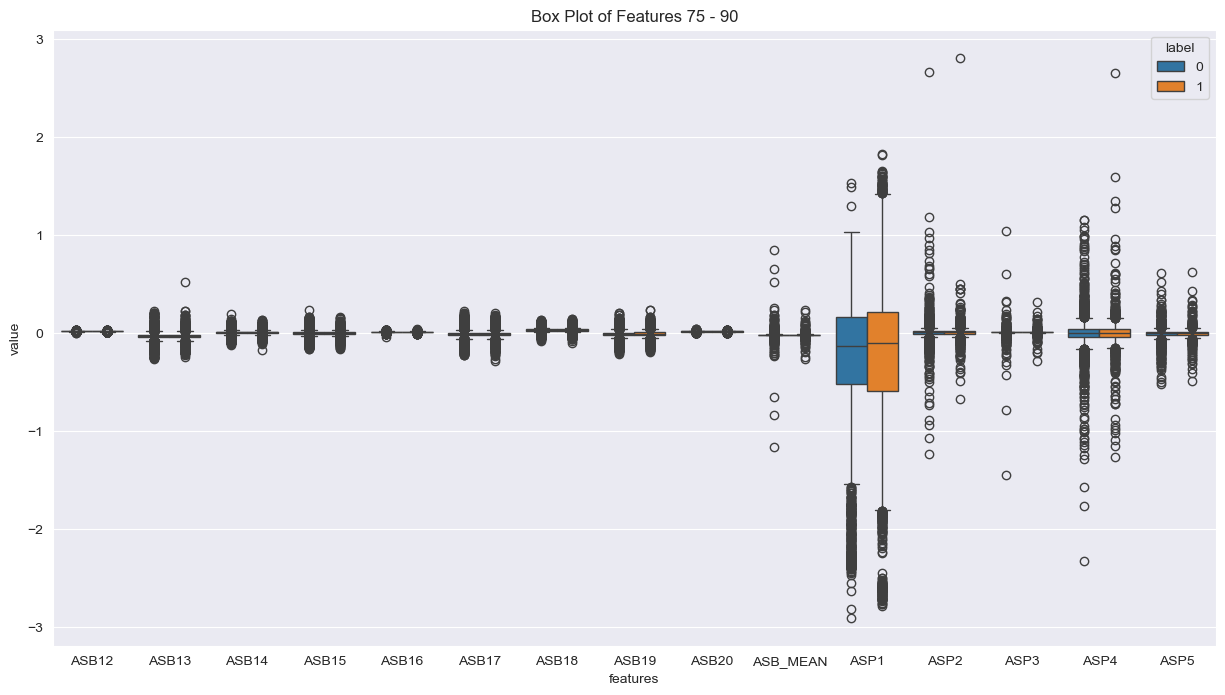

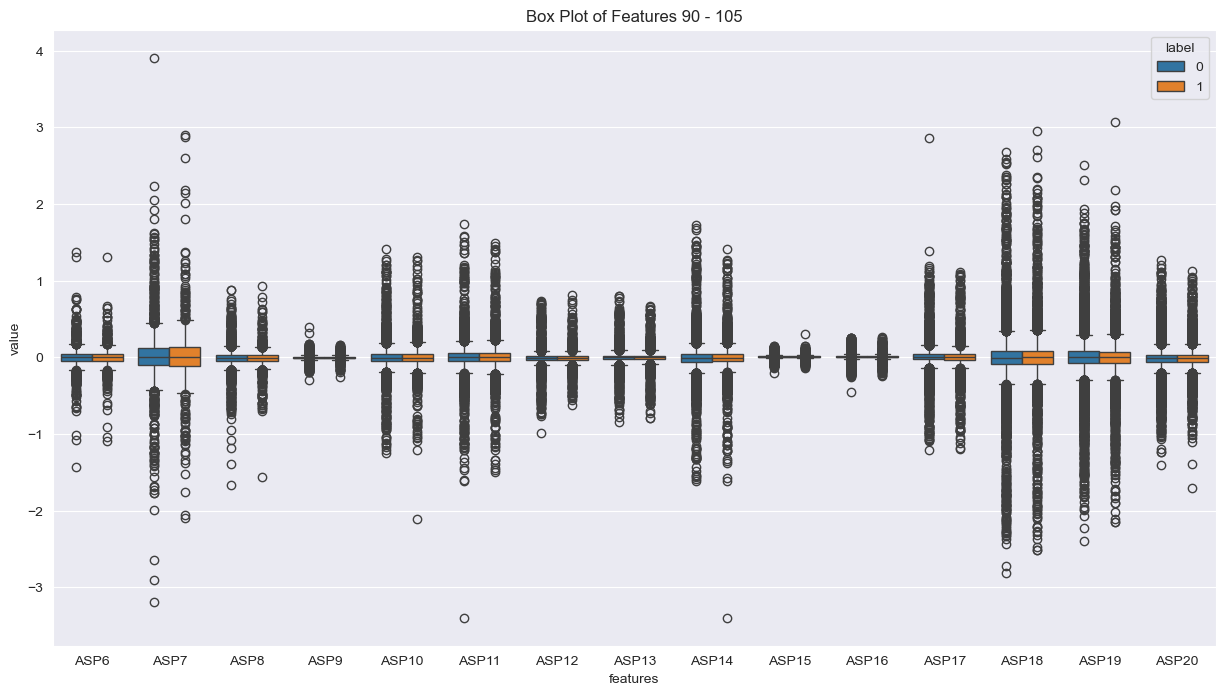

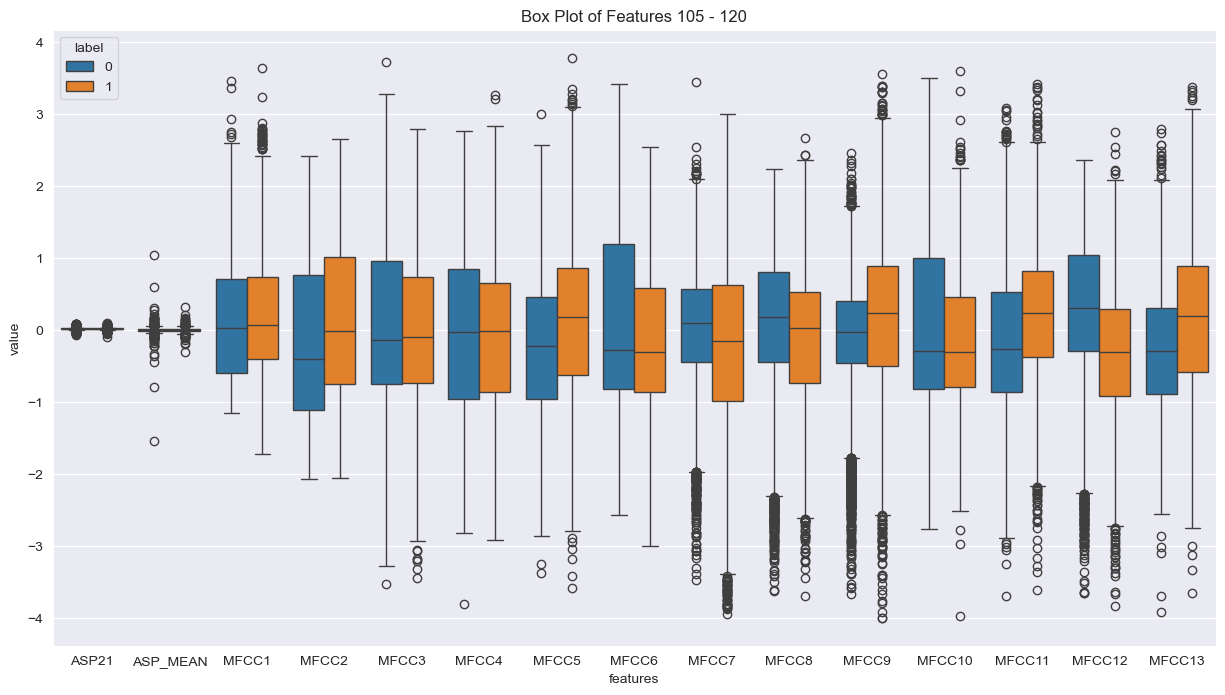

In [68]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_clipped.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.boxplot(x="features", y="value", hue="label", data=data_)
    plt.title(f"Box Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Violing Plots of data after Isolation Forest

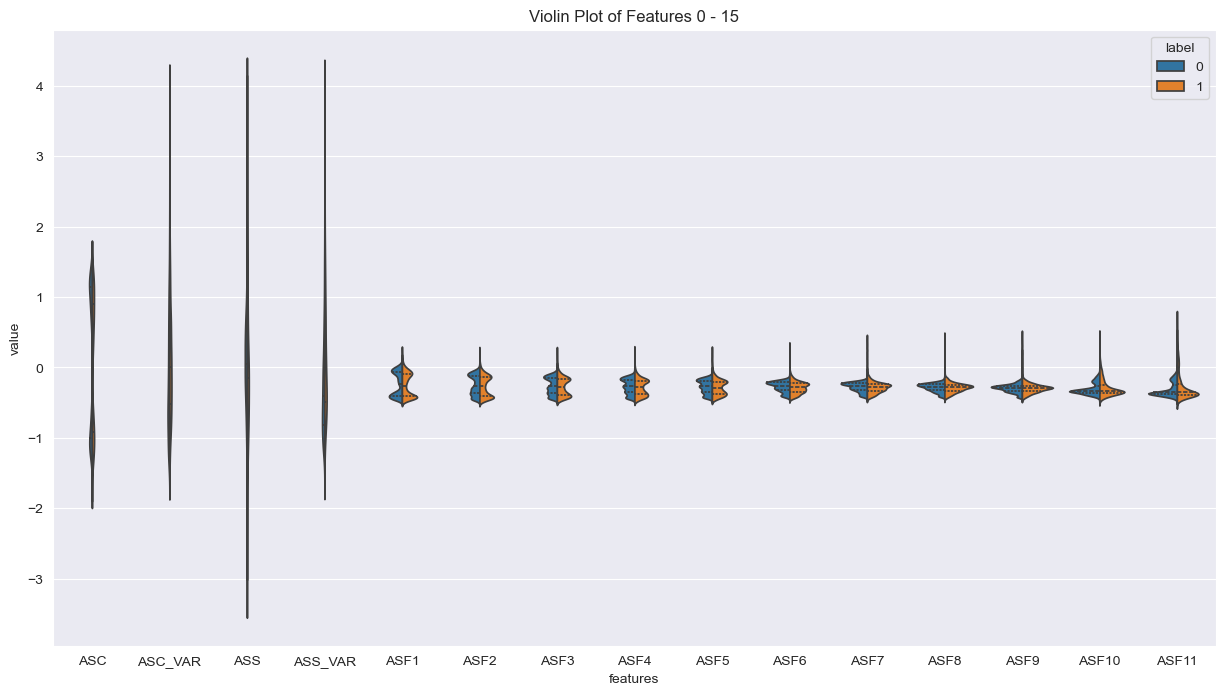

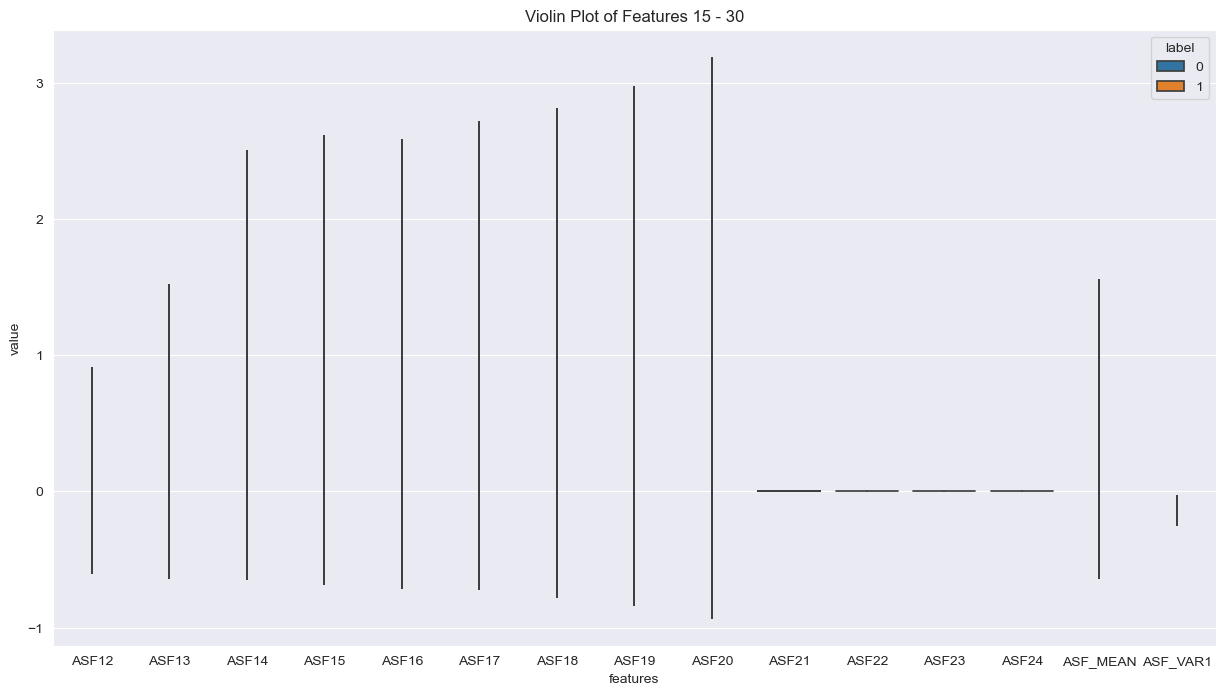

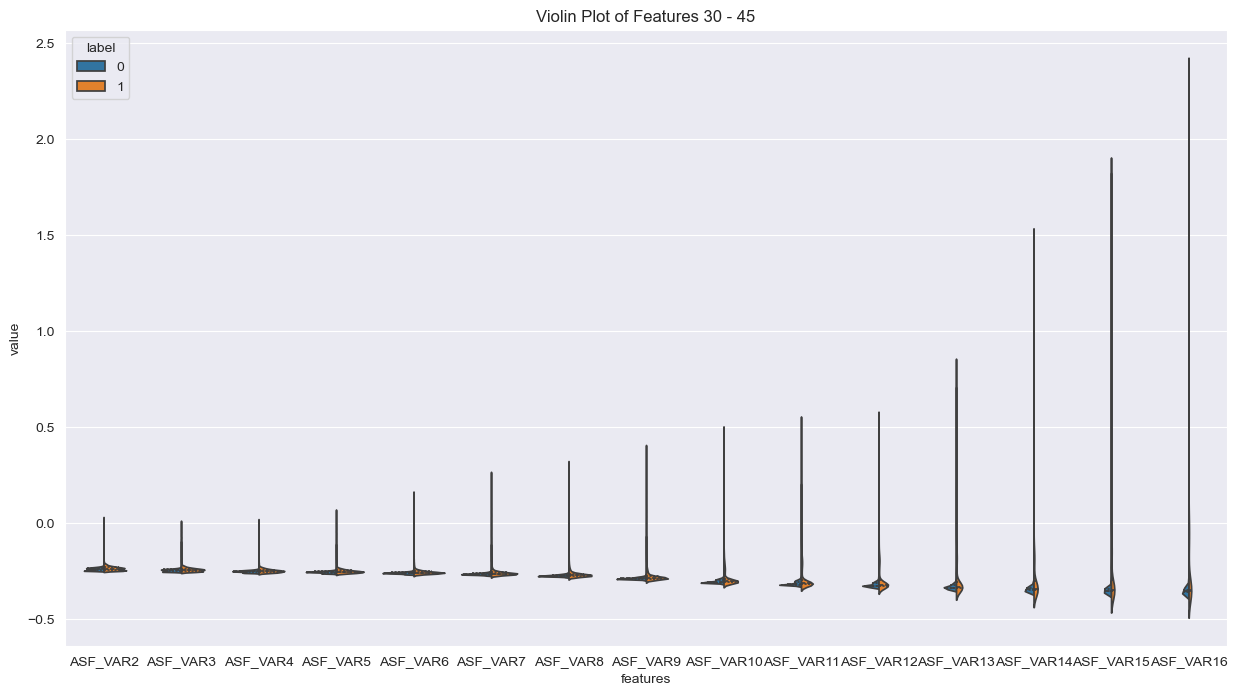

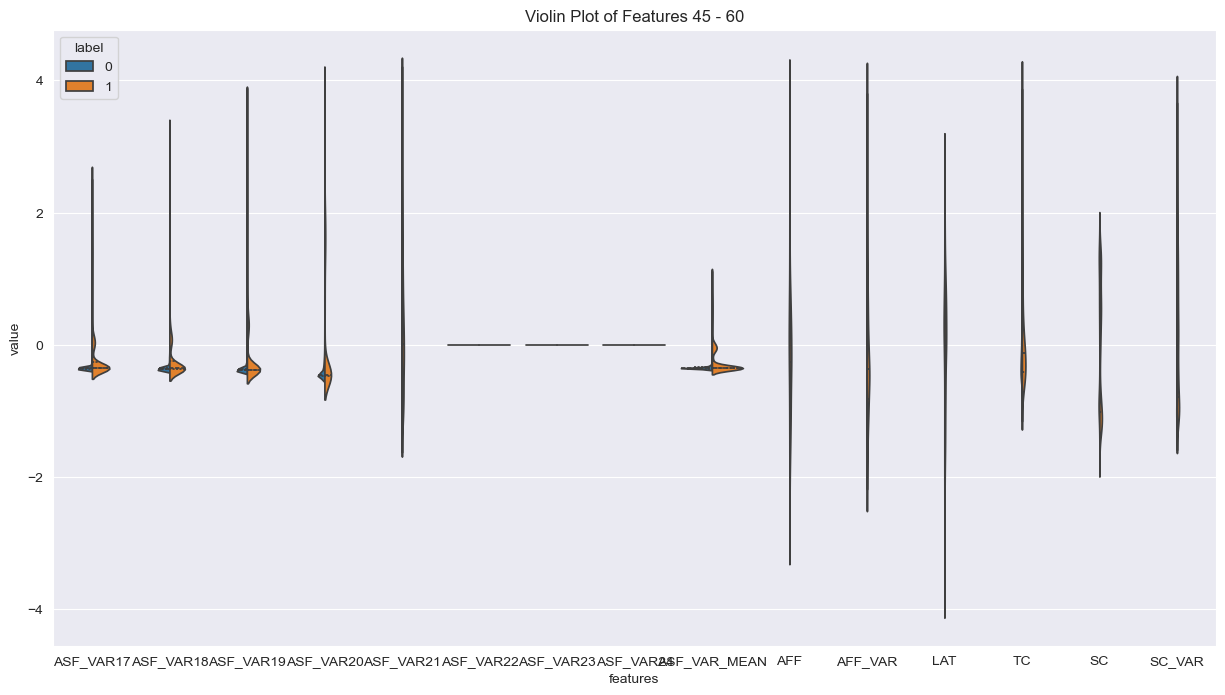

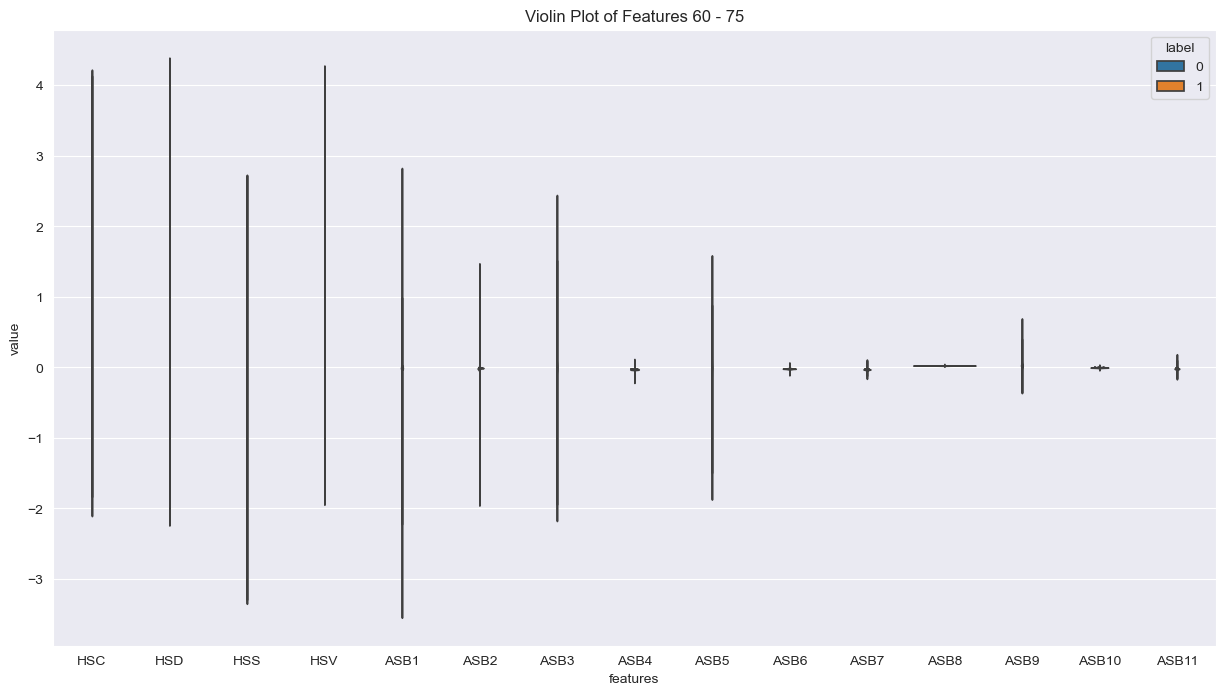

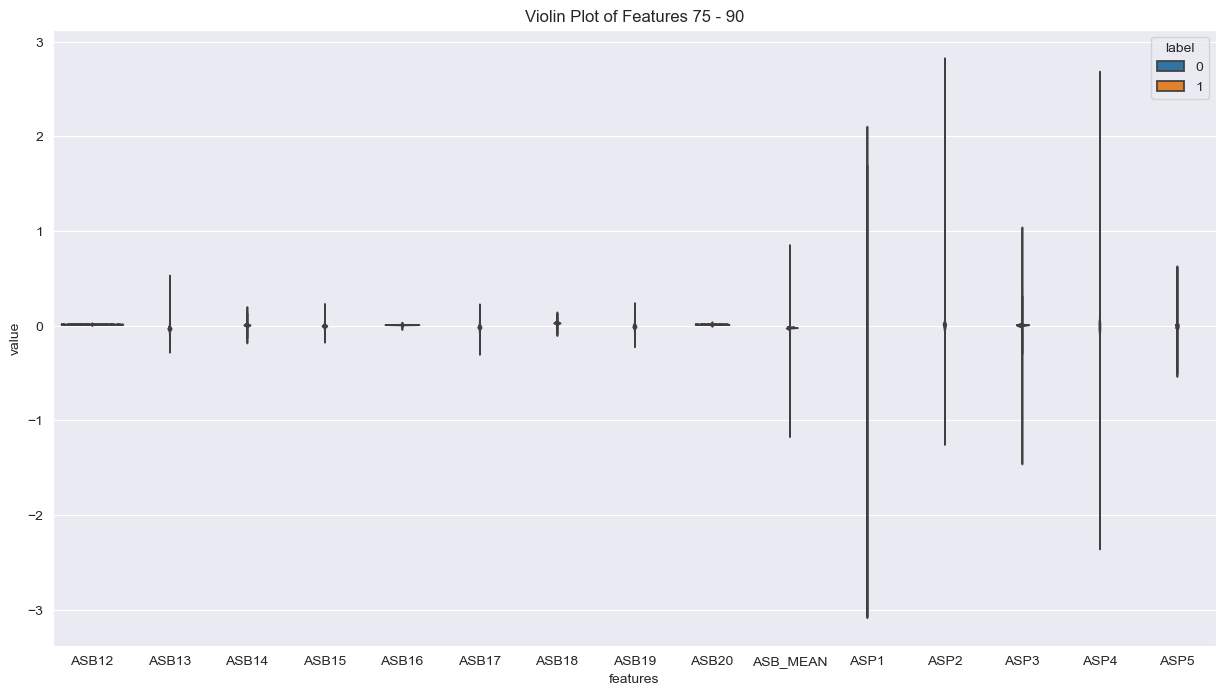

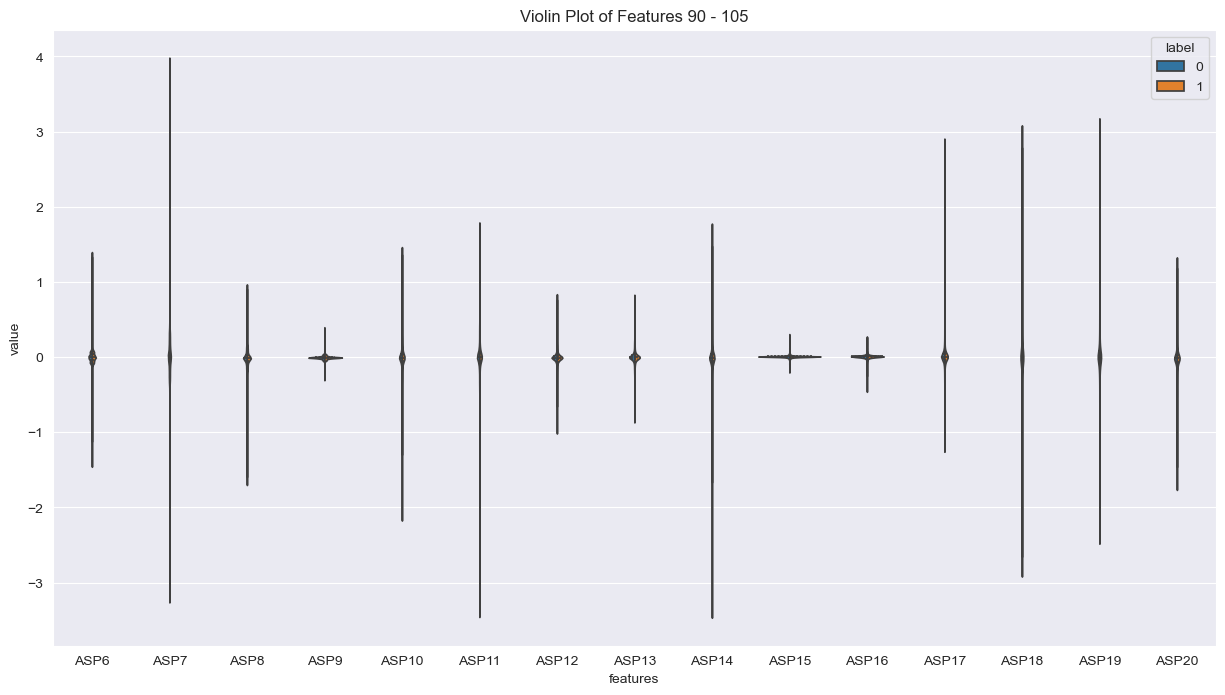

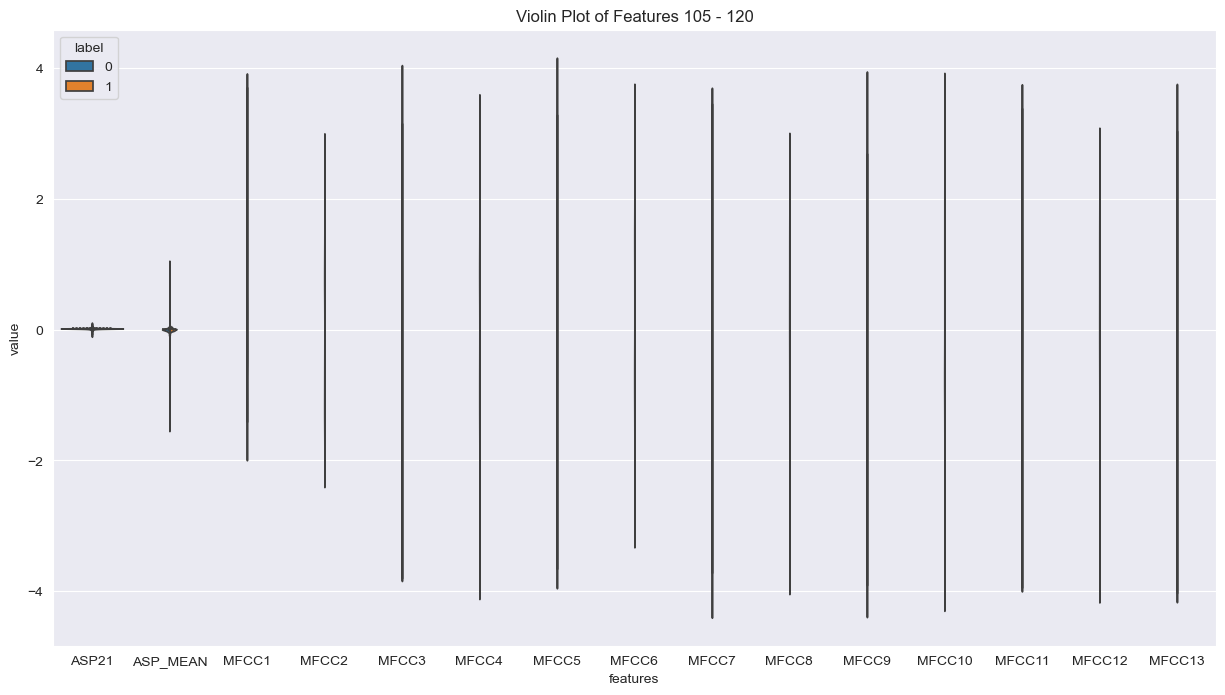

In [69]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_clipped.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.violinplot(x="features", y="value", hue="label", data=data_,
                   split=True, inner="quart")
    plt.title(f"Violin Plot of Features {indexes[i][0]} - {indexes[i][1]}")

## Save data without outliers

In [171]:
print("X shape: ", X_clipped.shape)
print("y shape: ", y_clipped.shape)
X_without_outliers = pd.DataFrame(X_clipped)
y_without_outliers = pd.Series(y_clipped)
data_without_outliers = pd.DataFrame(X_without_outliers)
X_without_outliers = pd.DataFrame(X_clipped).reset_index(drop=True)
y_without_outliers = pd.Series(y_clipped).reset_index(drop=True)


data_without_outliers = pd.concat([y_without_outliers, data_without_outliers], axis=1)
print("Number of NaN values:")
print(data_without_outliers.isna().sum().sum())
data_without_outliers.to_csv("Torgo_without_outliers.csv", index=False)
data_without_outliers.isna().sum()


X shape:  (14795, 127)
y shape:  (14795,)
Number of NaN values:
0


label    0
0        0
1        0
2        0
3        0
        ..
122      0
123      0
124      0
125      0
126      0
Length: 128, dtype: int64

## Feature selection

In [172]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier

clf  = ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf.fit(X_clipped, y_clipped)

print("Feature importance: \n", clf.feature_importances_)
model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X_clipped)
print("X shape: ", X_new.shape)
print("Number of features: \n", X_new.shape[1])

Feature importance: 
 [0.01381399 0.00711744 0.00881816 0.01639479 0.00770398 0.00880763
 0.00772509 0.00770734 0.00849784 0.00696729 0.00596112 0.00553699
 0.00551235 0.00621895 0.00829279 0.00906743 0.00813608 0.00830596
 0.01321034 0.02057419 0.01195109 0.01522464 0.01957796 0.03469618
 0.         0.         0.         0.         0.01356661 0.00940595
 0.00874204 0.01308525 0.00933973 0.00835052 0.00697986 0.00580675
 0.00806947 0.00531041 0.00774855 0.00860637 0.01313808 0.01150044
 0.00737082 0.01260064 0.00926575 0.01491391 0.01046341 0.00985788
 0.0174306  0.01053754 0.         0.         0.         0.0111508
 0.00966688 0.0082557  0.00946989 0.01931937 0.01415105 0.00846563
 0.00787985 0.03205103 0.00662287 0.01152035 0.00237401 0.00245094
 0.00269321 0.0023235  0.00253595 0.00243217 0.00266207 0.00228208
 0.00236328 0.00257509 0.00260231 0.00257193 0.00238242 0.00238077
 0.00253024 0.00270908 0.00256376 0.00251499 0.00261283 0.00251356
 0.00266285 0.01944299 0.0024882  0.00247

In [173]:

X_selected = pd.DataFrame(X_new).reset_index(drop=True)
y_selected = pd.Series(y_clipped).reset_index(drop=True)
data_selected = pd.concat([y_selected, X_selected], axis=1)
data_selected.to_csv("Torgo_selected.csv", index=False)
data_selected.isna().sum().sum()


np.int64(0)